[![](imagens/colab-badge.png){width="16%"}](https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/cap08/cap08_aluno.ipynb)
[![](imagens/github-badge.png){width="19%"}](https://github.com/fzampirolli/pdi-vc)

# Compreendendo Cenas: Correspondência de Características, Detecção e Segmentação

No **Capítulo 7**, foi estudado como representar imagens por meio de descritores e utilizar essas representações para tarefas de classificação. Neste capítulo, o problema é ampliado: além de reconhecer padrões, torna-se necessário estabelecer correspondências entre diferentes imagens, localizar automaticamente objetos de interesse e interpretar a organização espacial de uma cena.

Esses problemas constituem algumas das principais tarefas da Visão Computacional e representam uma etapa natural após a classificação de imagens. Para resolvê-los, serão apresentados métodos clássicos de correspondência de características, detecção de objetos e segmentação de imagens, bem como uma visão geral das abordagens modernas baseadas em *Deep Learning*, preparando a transição para o **Capítulo 9**.

## Objetivos do Capítulo

Ao concluir este capítulo, o estudante deverá ser capaz de:

- **Estabelecer correspondências entre imagens** utilizando detectores e descritores locais, estimando transformações geométricas por meio de homografias;
- **Localizar objetos de interesse** em imagens utilizando métodos clássicos de detecção e avaliar os resultados por meio de métricas como ***Intersection over Union* (IoU)** e ***Non-Maximum Suppression* (NMS)**;
- **Diferenciar os paradigmas de segmentação** — semântica, de instâncias e panóptica — e aplicar métodos clássicos de segmentação;
- **Extrair descritores geométricos e topológicos** de objetos segmentados e exportá-los como anotações estruturadas (CSV ou formato YOLO), validando-as por meio da métrica IoU;
- **Relacionar os métodos clássicos de correspondência, detecção e segmentação** com as abordagens modernas baseadas em *Deep Learning*, estudadas no **Capítulo 9**.

## Configuração do Ambiente


In [33]:
#| quarto-raw: true

import importlib
import subprocess
import sys

for mod, pkg in {
    "cv2": "opencv-python",
    "skimage": "scikit-image",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
}.items():
    try:
        importlib.import_module(mod)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

import cv2
import numpy as np
import importlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from skimage import data as skdata
from skimage.filters import threshold_otsu
from skimage.measure import label
from skimage.morphology import remove_small_objects, opening, disk

import os
import urllib.request

if not os.path.exists("morph.py"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/fzampirolli/pdi-vc/master/morph/morph.py",
        "morph.py",
    )

import morph
importlib.reload(morph); 
from morph import mm

print(f"✅ Ambiente pronto. morph {getattr(morph, '__version__', 'local_file')}")

✅ Ambiente pronto. morph 1.1.5


## Detectores e Descritores Locais de Características

No capítulo anterior, cada imagem foi representada por um único vetor de características utilizado para classificação. Em diversas aplicações, entretanto, é necessário comparar apenas partes da imagem, estabelecendo correspondências entre regiões observadas em diferentes instantes, posições ou pontos de vista. Essa tarefa requer uma representação local da imagem, capaz de identificar estruturas suficientemente distintas para serem reencontradas em outras imagens.

Esse processo é realizado em duas etapas complementares. Inicialmente, um **detector** identifica pontos de interesse (*keypoints*), normalmente associados a cantos ou regiões com variações significativas de intensidade. Em seguida, um **descritor** representa numericamente a vizinhança de cada ponto detectado, permitindo comparar regiões correspondentes entre diferentes imagens.

Uma vez obtidos os pares *(ponto, descritor)*, a correspondência (*matching*) consiste em encontrar, para cada descritor de uma imagem, o descritor mais semelhante na outra. Essas correspondências constituem a base de diversas aplicações, como registro de imagens, reconstrução tridimensional, navegação visual e realidade aumentada.

### O Algoritmo ORB (*Oriented FAST and Rotated BRIEF*)

Neste capítulo será utilizado o **ORB**, um detector e descritor local que combina eficiência computacional e robustez a rotações. O algoritmo reúne três componentes principais:

- **FAST** (*Features from Accelerated Segment Test*), responsável pela detecção dos pontos-chave;
- **BRIEF** (*Binary Robust Independent Elementary Features*), responsável pela construção do descritor binário;
- um mecanismo de **estimativa de orientação**, que torna o descritor aproximadamente invariante à rotação.

O detector **FAST** percorre todos os pixels da imagem. Para cada pixel candidato, analisa um círculo de **16 pixels** ao seu redor. Se um conjunto de pixels consecutivos apresentar intensidade significativamente maior ou menor que a intensidade do pixel central, esse pixel é considerado um **ponto-chave** (*keypoint*). Em seguida, candidatos muito próximos são filtrados, preservando apenas os mais representativos.

Após a detecção dos pontos-chave, o descritor **BRIEF** é calculado em uma vizinhança ao redor de cada ponto-chave, e não apenas sobre os 16 pixels utilizados pelo FAST. Nessa região, um conjunto fixo de pares de pontos $(x,y)$ é comparado segundo a @eq-brief. No ORB, esse padrão de amostragem é rotacionado de acordo com a orientação estimada do ponto-chave, reduzindo a sensibilidade à rotação.

$$
\tau(p;x,y)=
\begin{cases}
1,& \text{se } I(x)<I(y),\\
0,& \text{caso contrário},
\end{cases}
$$ {#eq-brief}

em que:

- $p$ é o ponto-chave detectado pelo FAST;
- $x$ e $y$ são dois pontos da vizinhança de $p$, escolhidos pelo padrão de amostragem do BRIEF;
- $I(\cdot)$ representa a intensidade de um pixel;
- $\tau(p;x,y)$ é o resultado da comparação binária entre os pontos $x$ e $y$.

A sequência dos bits produzidos por essas comparações constitui o descritor do ponto-chave.

Como o descritor é binário, a similaridade entre dois pontos é medida pela **distância de Hamming**, correspondente ao número de bits diferentes entre dois descritores. Essa métrica pode ser calculada de forma muito eficiente por operações lógicas sobre os bits, tornando o ORB adequado para aplicações em tempo real.


### Explorando o Simulador do ORB

A @fig-08-sim-orb ilustra, de forma interativa, como o descritor **ORB** é construído. 
Cada linha colorida (verde ou vermelha) representa um dos 32 pares de pontos $(x,y)$ 
utilizados na @eq-brief; a seta **amarela** indica o vetor de orientação estimado a 
partir do centróide de intensidade da vizinhança — é em torno dele que o padrão de 
amostragem gira, garantindo a invariância à rotação.

Inicialmente, deixe o ruído em zero e compare a sequência de bits com o slider em 0° 
e depois em 15° (anote o valor do campo "Assinatura do Descritor Binário" em cada caso):


```text
0°  : 00000000000000100000011111100010
15° : 00000000000000100000011111100010
```

Nesse exemplo, ambos os descritores são idênticos, e o painel "Dist. Hamming" 
confirma distância zero — evidência de que a estimativa de orientação está 
compensando corretamente a rotação da imagem.

Agora clique em "Adicionar Ruído" e repita o experimento. Como o ruído é gerado 
aleatoriamente a cada execução, os valores abaixo são apenas um exemplo — os seus 
serão diferentes, mas devem apresentar uma distância de Hamming de magnitude 
semelhante (tipicamente entre 6 e 14 bits, de um total de 32):

```text
0°  : 01000000001000110110011111101010
15° : 10110000001011100100111111100010
```

O ruído altera parte das comparações de intensidade, modificando alguns bits do descritor. A diferença entre dois descritores é medida pela **distância de Hamming**, correspondente ao número de posições em que os bits diferem. Para os descritores acima, essa distância é igual a **10**. 

Uma forma eficiente de calcular essa distância em Python consiste em aplicar a operação **XOR** (`^`), que identifica os bits diferentes, seguida do método `bit_count()`, que contabiliza quantos bits iguais a 1 existem no resultado.

In [34]:
def hamming(a: int, b: int) -> int:
    return (a ^ b).bit_count()
a = 0b01000000001000110110011111101010
b = 0b10110000001011100100111111100010
hamming(a, b)

10

A @fig-08-hamming-benchmark compara essa implementação com uma versão baseada na comparação de caracteres e com a implementação otimizada do OpenCV (`cv2.NORM_HAMMING`).

            Método  Tempo (s)  Speedup
0          Strings   1.245348      1.0
1  XOR+bit_count()   0.012624     98.6
2           OpenCV   0.162813      7.6


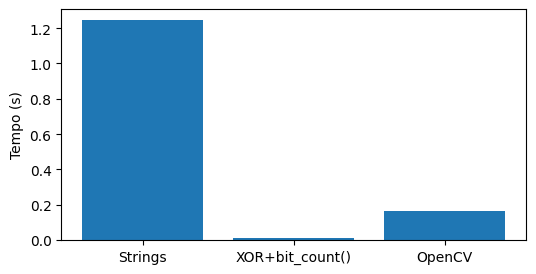

In [35]:
#| quarto-raw: true
#| label: fig-08-hamming-benchmark
#| echo: true
#| fig-cap: "Comparação do desempenho de diferentes implementações da distância de Hamming."

import random, timeit, cv2, numpy as np, pandas as pd
import matplotlib.pyplot as plt

BITS, N = 256, 100_000
A = [''.join(random.choice('01') for _ in range(BITS)) for _ in range(N)]
B = [''.join(random.choice('01') for _ in range(BITS)) for _ in range(N)]
Ai, Bi = map(lambda L: [int(x,2) for x in L], (A,B))
Acv = np.array([[int(s[i:i+8],2) for i in range(0,BITS,8)] for s in A], np.uint8)
Bcv = np.array([[int(s[i:i+8],2) for i in range(0,BITS,8)] for s in B], np.uint8)

H = [
    ("Strings", lambda: sum(sum(x!=y for x,y in zip(a,b)) for a,b in zip(A,B))),
    ("XOR+bit_count()", lambda: sum((a^b).bit_count() for a,b in zip(Ai,Bi))),
    ("OpenCV", lambda: sum(cv2.norm(a,b,cv2.NORM_HAMMING) for a,b in zip(Acv,Bcv)))
]

df = pd.DataFrame(
    [(n, timeit.timeit(f, number=1)) for n,f in H],
    columns=["Método","Tempo (s)"]
)
df["Speedup"] = (df.iloc[0,1]/df["Tempo (s)"]).round(1)

print(df)

plt.figure(figsize=(6,3))
plt.bar(df["Método"], df["Tempo (s)"])
plt.ylabel("Tempo (s)")
plt.show()

In [36]:
#| label: fig-08-sim-orb
#| fig-cap: "Simulador interativo do descritor ORB: explore a lógica de rotação e construção do descritor binário. Altere a rotação para observar como o padrão de amostragem de testes binários do BRIEF (linhas verdes e vermelhas) se orienta dinamicamente para garantir a invariância angular."
#| echo: false
#| output: true

from IPython.display import HTML
HTML("""
<div id="orb8_Root">
<style>
  #orb8_Root * { box-sizing: border-box; }
  #orb8_Root { font-family: sans-serif; padding: 10px; max-width: 760px; margin: 0 auto; color: #374151; }
  #orb8_Root canvas { display: block; border-radius: 6px; border: 1px solid #d1d5db; background: #111827; margin: 0 auto; }
  #orb8_Root button { font-size: 11px; padding: 6px 12px; border-radius: 4px; border: 1px solid #d1d5db; background: #fff; color: #374151; cursor: pointer; transition: background 0.15s; }
  #orb8_Root button:hover { background: #f3f4f6; }
  #orb8_Root button.orb8_active { background: #4f46e5; color: #fff; border-color: #4f46e5; }
  #orb8_Root input[type=range] { width: 100%; accent-color: #6366f1; }
  .orb8_panel { background: #f9fafb; border: 1px solid #e5e7eb; border-radius: 6px; padding: 10px; margin-bottom: 8px; }
  .orb8_row { display: flex; align-items: center; gap: 10px; flex-wrap: wrap; }
  .orb8_stat { background: #f9fafb; border: 1px solid #e5e7eb; border-radius: 6px; padding: 8px 14px; text-align: center; min-width: 90px; }
  .orb8_stat_label { font-size: 9px; color: #6b7280; text-transform: uppercase; letter-spacing: 0.05em; margin-bottom: 2px; }
  .orb8_stat_value { font-size: 18px; font-weight: bold; font-family: monospace; color: #4f46e5; }
  .orb8_pill { font-size: 10px; font-weight: bold; padding: 3px 8px; border-radius: 4px; border: 1px solid #a5b4fc; background: #eef2ff; color: #4338ca; }
  .orb8_legend { display: flex; align-items: center; gap: 6px; font-size: 11px; }
  .orb8_dot { width: 10px; height: 10px; border-radius: 50%; display: inline-block; border: 1px solid rgba(0,0,0,0.2); }
  .orb8_bitstream { font-family: monospace; word-break: break-all; background: #1f2937; color: #10b981; padding: 8px; border-radius: 4px; font-size: 11px; max-height: 50px; overflow-y: auto; text-shadow: 0 0 2px rgba(16,185,129,0.5); }
</style>

<div class="orb8_panel" style="display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
  <span style="font-size:12px;font-weight:bold;color:#4b5563;">🎯 Simulador Interativo: Alinhamento de Orientação e BRIEF (ORB)</span>
  <span class="orb8_pill">Invariância de Orientação em Tempo Real</span>
</div>

<div class="orb8_panel">
  <div class="orb8_row" style="margin-bottom:8px;">
    <div class="orb8_stat"><div class="orb8_stat_label">Ângulo (θ)</div><div id="orb8_angVal" class="orb8_stat_value">0°</div></div>
    <div class="orb8_stat"><div class="orb8_stat_label">Dist. Hamming</div><div id="orb8_hammVal" class="orb8_stat_value">0</div></div>
    <div class="orb8_stat"><div class="orb8_stat_label">Pares Ativos</div><div id="orb8_pairsVal" class="orb8_stat_value">32</div></div>
    <button id="orb8_btnRot">Girar +15°</button>
    <button id="orb8_btnReset">Resetar Ângulo</button>
    <button id="orb8_btnNoise">Adicionar Ruído</button>
  </div>
  <label style="font-size:11px;font-weight:600;color:#374151;">Ângulo de Rotação Aplicado à Imagem: <span id="orb8_slVal">0</span>°</label>
  <input type="range" id="orb8_slider" min="-180" max="180" step="5" value="0">
</div>

<canvas id="orb8_canvas" width="640" height="340"></canvas>

<div class="orb8_panel" style="margin-top:10px;">
  <div style="font-size:11px; font-weight:600; color:#374151; margin-bottom:4px;">Assinatura do Descritor Binário Gerada (BRIEF 32-bits):</div>
  <div id="orb8_bits" class="orb8_bitstream">00000000000000000000000000000000</div>
  <div class="orb8_row" style="justify-content:space-between; margin-top:8px;">
    <div class="orb8_legend"><span style="width:12px; height:2px; background:#10b981; display:inline-block;"></span> Teste = 1 (I(A) &lt; I(B))</div>
    <div class="orb8_legend"><span style="width:12px; height:2px; background:#ef4444; display:inline-block;"></span> Teste = 0 (I(A) ≥ I(B))</div>
    <div style="font-size:11px;color:#6b7280;">A linha amarela indica o vetor centroide da orientação estimada.</div>
  </div>
</div>
</div>

<script>
(function(){
  const canvas = document.getElementById("orb8_canvas");
  const ctx = canvas.getContext("2d");
  const W = canvas.width, H = canvas.height;

  let angleDeg = 0;
  let noiseLevel = 0;
  
  const numPairs = 32;
  const pairsSource = [];
  
  // Gerar pares pseudo-aleatórios determinísticos de teste BRIEF
  for (let i = 0; i < numPairs; i++) {
    const r1 = 5 + (i * 1.1) % 35;
    const t1 = (i * 2.39) % (2 * Math.PI);
    const r2 = 5 + (i * 1.7) % 35;
    const t2 = (i * 3.14) % (2 * Math.PI);
    pairsSource.push({
      ax: r1 * Math.cos(t1), ay: r1 * Math.sin(t1),
      bx: r2 * Math.cos(t2), by: r2 * Math.sin(t2)
    });
  }

  // Gera uma vizinhança sintética (padrão de canto artificial na imagem)
  function getPixelIntensity(px, py, rotationRad) {
    const c = Math.cos(-rotationRad);
    const s = Math.sin(-rotationRad);
    const rx = px * c - py * s;
    const ry = px * s + py * c;

    let val = 128;
    if (rx > 0 && ry > 0) val = 200; 
    if (rx < -5 && ry > 5) val = 45; 
    if (rx * rx + ry * ry < 15 * 15) val = 220; 
    
    if (noiseLevel > 0) {
      val += (Math.random() - 0.5) * noiseLevel;
    }
    return Math.min(255, Math.max(0, val));
  }

  function getCentroidOrientation(rotationRad) {
    let m10 = 0, m01 = 0;
    const step = 4;
    const R = 30;
    for (let x = -R; x <= R; x += step) {
      for (let y = -R; y <= R; y += step) {
        if (x*x + y*y <= R*R) {
          const intensity = getPixelIntensity(x, y, rotationRad);
          m10 += x * intensity;
          m01 += y * intensity;
        }
      }
    }
    return Math.atan2(m01, m10);
  }

  function render() {
    ctx.clearRect(0, 0, W, H);

    const leftCenterX = W / 4, rightCenterX = 3 * W / 4;
    const centerY = H / 2;
    const patchRadius = 80;

    // 1. Desenhar a imagem de fundo de ambos os lados
    drawPatchBg(leftCenterX, centerY, patchRadius, 0);
    drawPatchBg(rightCenterX, centerY, patchRadius, angleDeg * Math.PI / 180);

    // 2. Computar orientações locais (centroide de intensidade)
    const orientOriginal = getCentroidOrientation(0);
    const angleRad = angleDeg * Math.PI / 180;
    const orientRotated = getCentroidOrientation(angleRad);

    // 3. Gerar descritores (orientando os pares de teste conforme a direção estimada)
    const descOriginal = computeDescriptor(0, orientOriginal);
    const descRotated = computeDescriptor(angleRad, orientRotated);

    // 4. Desenhar os testes e marcadores do BRIEF
    drawBriefTestGrid(leftCenterX, centerY, 0, orientOriginal, descOriginal);
    drawBriefTestGrid(rightCenterX, centerY, angleRad, orientRotated, descRotated);

    // 5. Linhas de orientação calculada
    drawOrientationArrow(leftCenterX, centerY, orientOriginal);
    drawOrientationArrow(rightCenterX, centerY, orientRotated);

    // 6. Calcular distância de Hamming
    let hammingDist = 0;
    for (let i = 0; i < numPairs; i++) {
      if (descOriginal[i] !== descRotated[i]) hammingDist++;
    }

    document.getElementById("orb8_bits").textContent = descRotated.join("");
    document.getElementById("orb8_hammVal").textContent = hammingDist;
    document.getElementById("orb8_angVal").textContent = angleDeg + "°";
    document.getElementById("orb8_slVal").textContent = angleDeg;
     
    document.getElementById("orb8_noiseVal").textContent = noiseLevel;
    
    ctx.font = "bold 12px sans-serif";
    ctx.fillStyle = "#ffffff";
    ctx.textAlign = "center";
    ctx.fillText("Vizinhança Original (θ = 0°)", leftCenterX, centerY - patchRadius - 15);
    ctx.fillText("Vizinhança Rotacionada (θ-alinhado)", rightCenterX, centerY - patchRadius - 15);

    ctx.strokeStyle = "#374151";
    ctx.lineWidth = 1;
    ctx.beginPath();
    ctx.moveTo(W / 2, 10);
    ctx.lineTo(W / 2, H - 10);
    ctx.stroke();
  }

  function drawPatchBg(cx, cy, r, rotationRad) {
    const cellSize = 5;
    for (let x = -r; x < r; x += cellSize) {
      for (let y = -r; y < r; y += cellSize) {
        if (x*x + y*y <= r*r) {
          const intensity = getPixelIntensity(x, y, rotationRad);
          ctx.fillStyle = `rgb(${intensity}, ${intensity}, ${intensity})`;
          ctx.fillRect(cx + x, cy + y, cellSize, cellSize);
        }
      }
    }
    ctx.strokeStyle = "#4b5563";
    ctx.lineWidth = 2;
    ctx.beginPath();
    ctx.arc(cx, cy, r, 0, 2*Math.PI);
    ctx.stroke();
  }

  function computeDescriptor(rotationRad, estimatedOrient) {
    const desc = [];
    for (let i = 0; i < numPairs; i++) {
      const p = pairsSource[i];
      const c = Math.cos(estimatedOrient);
      const s = Math.sin(estimatedOrient);

      const axRot = p.ax * c - p.ay * s;
      const ayRot = p.ax * s + p.ay * c;
      const bxRot = p.bx * c - p.by * s;
      const byRot = p.bx * s + p.by * c;

      const valA = getPixelIntensity(axRot, ayRot, rotationRad);
      const valB = getPixelIntensity(bxRot, byRot, rotationRad);

      desc.push(valA < valB ? 1 : 0);
    }
    return desc;
  }

  function drawBriefTestGrid(cx, cy, rotationRad, estimatedOrient, desc) {
    const c = Math.cos(estimatedOrient);
    const s = Math.sin(estimatedOrient);

    for (let i = 0; i < numPairs; i++) {
      const p = pairsSource[i];
      const axRot = cx + (p.ax * c - p.ay * s);
      const ayRot = cy + (p.ax * s + p.ay * c);
      const bxRot = cx + (p.bx * c - p.by * s);
      const byRot = cy + (p.bx * s + p.by * c);

ctx.strokeStyle = desc[i] === 1 ? "rgba(16, 185, 129, 0.9)" : "rgba(239, 68, 68, 0.9)";
ctx.lineWidth = 2;
     
      ctx.beginPath();
      ctx.moveTo(axRot, ayRot);
      ctx.lineTo(bxRot, byRot);
      ctx.stroke();

      ctx.fillStyle = "rgba(16, 185, 129, 0.8)";
      ctx.fillRect(axRot - 1.5, ayRot - 1.5, 3, 3);
      ctx.fillStyle = "rgba(239, 68, 68, 0.8)";
      ctx.fillRect(bxRot - 1.5, byRot - 1.5, 3, 3);
    }
  }

  function drawOrientationArrow(cx, cy, orient) {
    const arrowLen = 50;
    const ax = cx + arrowLen * Math.cos(orient);
    const ay = cy + arrowLen * Math.sin(orient);

    ctx.strokeStyle = "#eab308";
    ctx.lineWidth = 2.5;
    ctx.beginPath();
    ctx.moveTo(cx, cy);
    ctx.lineTo(ax, ay);
    ctx.stroke();

    ctx.beginPath();
    ctx.arc(cx, cy, 4, 0, 2*Math.PI);
    ctx.fillStyle = "#eab308";
    ctx.fill();
    
    const angle = Math.atan2(ay - cy, ax - cx);
    ctx.beginPath();
    ctx.moveTo(ax, ay);
    ctx.lineTo(ax - 8 * Math.cos(angle - Math.PI / 6), ay - 8 * Math.sin(angle - Math.PI / 6));
    ctx.lineTo(ax - 8 * Math.cos(angle + Math.PI / 6), ay - 8 * Math.sin(angle + Math.PI / 6));
    ctx.closePath();
    ctx.fillStyle = "#eab308";
    ctx.fill();
  }

  const slider = document.getElementById("orb8_slider");
  slider.addEventListener("input", function(ev){
    angleDeg = parseInt(ev.target.value, 10);
    render();
  });

  document.getElementById("orb8_btnRot").addEventListener("click", function(){
    angleDeg = (angleDeg + 15) % 180;
    if (angleDeg > 180) angleDeg -= 360;
    slider.value = angleDeg;
    render();
  });

document.getElementById("orb8_btnReset").addEventListener("click", function(){
    angleDeg = 0;
    noiseLevel = 0;
    slider.value = 0;
    const btnNoise = document.getElementById("orb8_btnNoise");
    btnNoise.classList.remove("orb8_active");
    btnNoise.textContent = "Adicionar Ruído";
    render();
});

const noiseStep = 15;
const maxNoise = 150;
document.getElementById("orb8_btnNoise").addEventListener("click", function(){
    noiseLevel = Math.min(noiseLevel + noiseStep, maxNoise);
    this.textContent = "Adicionar Ruído (" + noiseLevel + ")";
    this.classList.toggle("orb8_active", noiseLevel > 0);
    render();
});

  render();
})();
</script>
""")

## Projeto Prático 1: Correspondência de Características e Homografia com ORB

Para ilustrar o processo de correspondência de características, utiliza-se uma cena sintética obtida pela rotação de 20° da imagem original. Essa transformação simula uma segunda captura da mesma cena sob outro ponto de vista. A @fig-08-cena-sintetica apresenta a imagem de referência e sua versão rotacionada, que serão utilizadas nas etapas seguintes.

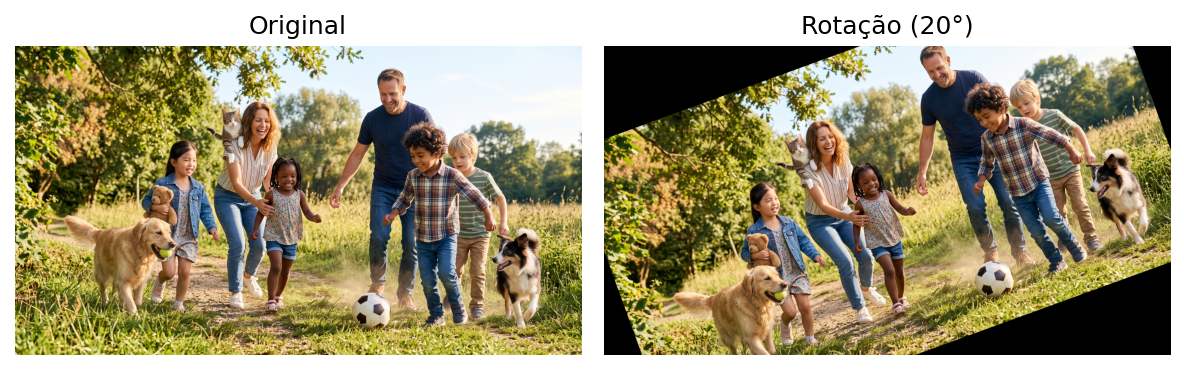

In [37]:
#| label: fig-08-cena-sintetica
#| fig-cap: "Imagem original gerada pelo Gemini e versão rotacionada (20°), simulando uma mudança de ponto de vista."
#| echo: true
#| output: true

caminho_local = "dados/fig-08-Gemini-faces3.png"
url_imagem = "https://raw.githubusercontent.com/fzampirolli/pdi-vc/master/all/cap08/" + caminho_local

if not os.path.exists(caminho_local):
    mm.write(mm.read(url_imagem), caminho_local)

img_original = mm.read(caminho_local)
img_cena = mm.rotate(img_original, angle=20)

mm.show([img_original, img_cena],
        titles=["Original", "Rotação (20°)"],
        cols=2, figsize=(8, 4))

### Detectando e Correspondendo Características com ORB

Com as duas imagens disponíveis, aplica-se o **ORB** para detectar pontos de interesse e calcular seus descritores. Em seguida, as correspondências são obtidas com o **BFMatcher**, utilizando distância de Hamming e verificação mútua (*cross-check*). Por fim, as correspondências são ordenadas da menor para a maior distância, priorizando os pares potencialmente mais confiáveis.

1. `cv2.ORB_create(nfeatures=500)` instancia o detector, limitando a busca aos 500 
   pontos-chave mais fortes de cada imagem (evita ruído de pontos pouco distintivos);
2. `orb.detectAndCompute(...)` executa o FAST (detecção) e o BRIEF orientado 
   (descrição) em uma única chamada, retornando os pontos-chave (`kp`) e seus 
   descritores binários de 256 bits (`des`);
3. `cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)` cria um comparador de força 
   bruta que usa a distância de Hamming — a mesma métrica explorada na 
   @fig-08-sim-orb — para comparar cada descritor da imagem original contra todos 
   os da cena rotacionada. `crossCheck=True` mantém apenas os pares em que a melhor 
   correspondência é mútua (A→B e B→A concordam), descartando associações 
   ambíguas;
4. `matches = sorted(...)` ordena as correspondências da menor para a maior 
   distância de Hamming, ou seja, das mais confiáveis para as mais duvidosas.

A @fig-08-orb-matches apresenta apenas as cinco correspondências de menor distância. Como ainda não há qualquer restrição geométrica, algumas ligações podem representar falsas correspondências, motivando o uso do RANSAC na etapa seguinte.


Pontos de interesse detectados: 500 (original), 500 (cena)
Correspondências encontradas: 300


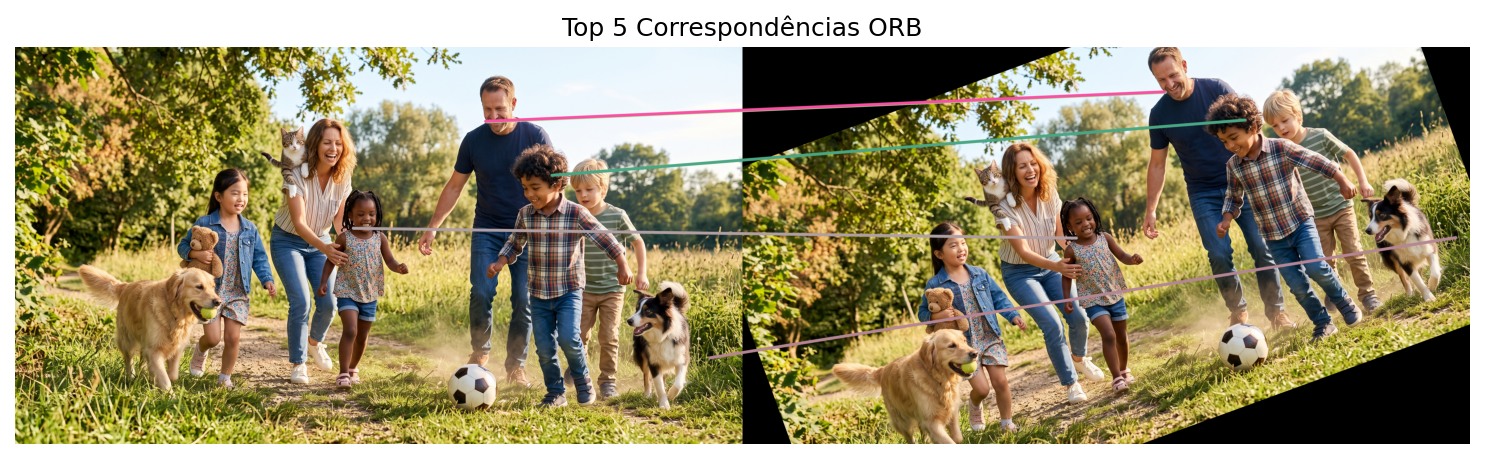

In [38]:
#| label: fig-08-orb-matches
#| fig-cap: "As 5 melhores correspondências de características ORB entre a imagem original e a cena sintética, antes da filtragem por RANSAC."
#| echo: true
#| output: true

orb = cv2.ORB_create(nfeatures=500)
kp1, des1 = orb.detectAndCompute(img_original, None)
kp2, des2 = orb.detectAndCompute(img_cena, None)
print(f"Pontos de interesse detectados: {len(kp1)} (original), {len(kp2)} (cena)")

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = sorted(
    bf.match(des1, des2),
    key=lambda m: m.distance
)
print(f"Correspondências encontradas: {len(matches)}")

def draw_matches_destacado(img1, kp1, img2, kp2, matches, espessura=2, raio_ponto=4,
                            seed=42, cor_fixa=None):
    """Desenha as imagens lado a lado com linhas conectando os pontos correspondentes.
    Se cor_fixa=None, cada correspondência recebe uma cor aleatória (facilita distinguir
    ligações individuais). Se cor_fixa for definida (ex: verde), todas as linhas usam a
    mesma cor — útil para destacar um subconjunto específico, como os inliers do RANSAC.
    """
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    h = max(h1, h2)
    canvas = np.zeros((h, w1 + w2, 3), dtype=np.uint8)
    canvas[:h1, :w1] = cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR) if img1.ndim == 2 else img1
    canvas[:h2, w1:w1+w2] = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR) if img2.ndim == 2 else img2

    rng = np.random.RandomState(seed)  # seed fixa = cores reproduzíveis a cada execução

    for m in matches:
        pt1 = tuple(np.round(kp1[m.queryIdx].pt).astype(int))
        pt2 = tuple(np.round(kp2[m.trainIdx].pt).astype(int) + np.array([w1, 0]))

        cor = cor_fixa if cor_fixa is not None else tuple(int(c) for c in rng.randint(60, 256, size=3))

        cv2.line(canvas, pt1, pt2, cor, espessura, lineType=cv2.LINE_AA)
        cv2.circle(canvas, pt1, raio_ponto, cor, -1, lineType=cv2.LINE_AA)
        cv2.circle(canvas, pt2, raio_ponto, cor, -1, lineType=cv2.LINE_AA)

    return canvas

# experimente as 5 piores: matches[-5:]
img_matches = draw_matches_destacado(
    img_original, kp1, img_cena, kp2, matches[:5],
    espessura=10, raio_ponto=4
)
mm.show([img_matches], titles=["Top 5 Correspondências ORB"], cols=1, figsize=(10, 5))

A função `draw_matches_destacado()` possui apenas finalidade de visualização: ela posiciona as imagens lado a lado e desenha linhas entre os pares correspondentes, não interferindo na estimação das correspondências.

## Modelagem Matemática: Homografia e RANSAC

### Homografia

Uma homografia é uma transformação projetiva representada por uma matriz $3\times3$, capaz de relacionar as coordenadas de um mesmo plano observado sob diferentes pontos de vista:

$$
\begin{bmatrix}
x'\\
y'\\
w'
\end{bmatrix}
=
\begin{bmatrix}
h_{11} & h_{12} & h_{13}\\
h_{21} & h_{22} & h_{23}\\
h_{31} & h_{32} & h_{33}
\end{bmatrix}
\begin{bmatrix}
x\\
y\\
1
\end{bmatrix}.
$$

Após a normalização das coordenadas homogêneas, obtém-se o ponto correspondente

$$
\left(\frac{x'}{w'},\frac{y'}{w'}\right).
$$

Como a homografia possui oito graus de liberdade (a matriz é definida a menos de um fator de escala), são necessários, no mínimo, **quatro pares de pontos correspondentes** para estimá-la. Na prática, entretanto, o conjunto de correspondências produzido pelo ORB contém inevitavelmente alguns pares incorretos (*outliers*), tornando necessária uma estimação robusta.

### RANSAC

O **RANSAC** (*Random Sample Consensus*) resolve esse problema estimando repetidamente um modelo geométrico — no caso da homografia, a partir de pequenos subconjuntos aleatórios de correspondências.

Em cada iteração, o algoritmo:

1. seleciona aleatoriamente um pequeno subconjunto de correspondências (quatro pares de pontos, no caso da homografia);
2. calcula um modelo candidato a partir desse subconjunto;
3. verifica quantas correspondências são compatíveis com essa transformação, classificando-as como ***inliers*** ou ***outliers***;
4. mantém o modelo com o maior número de ***inliers***;
5. recalcula o modelo final utilizando apenas os ***inliers*** encontrados.

Nesse projeto, o modelo estimado é uma **homografia**, utilizada para relacionar duas imagens da mesma cena. Entretanto, o RANSAC é um algoritmo de propósito geral e pode ser empregado para estimar diversos modelos geométricos, como retas, circunferências, planos ou transformações projetivas. Em todos os casos, seu funcionamento é o mesmo: gerar modelos candidatos a partir de pequenas amostras aleatórias e selecionar aquele que apresenta o maior consenso entre os dados.

Por esse motivo, antes de aplicá-lo à homografia, apresentamos dois simuladores mais simples, que isolam etapas diferentes do mesmo raciocínio.

O primeiro, na @fig-08-sim-ransac, utiliza o exemplo mais elementar possível: o ajuste de uma **reta** a um conjunto de pontos contendo aproximadamente 25% de *outliers*. Aqui o objetivo é apenas entender o mecanismo do algoritmo — amostrar, testar consenso, repetir, refinar — sem a complicação adicional de trabalhar com duas imagens.

O segundo, na @fig-08-sim-ransac-registro, aproxima o problema do caso real: em vez de um único conjunto de pontos, há **duas imagens**, e o que se observa são *correspondências* entre pontos-chave de uma e de outra — algumas corretas (*inliers*) e outras espúrias, resultantes de erros no casamento de descritores (*outliers*). O modelo estimado aqui é uma transformação de similaridade (rotação, escala e translação), mais simples que uma homografia completa, mas que já captura a essência do problema de registro: encontrar a transformação que alinha a maioria das correspondências, descartando os casamentos incorretos.

Em ambos os simuladores, o algoritmo executado é exatamente o mesmo utilizado posteriormente para estimar a homografia entre as duas imagens — muda apenas a natureza do modelo geométrico sendo ajustado.

Ajuste o limiar de distância e execute o algoritmo em cada simulador para observar como o RANSAC identifica os ***inliers***, descarta os ***outliers*** e ajusta o modelo utilizando apenas os pontos consistentes.

In [53]:
#| label: fig-08-sim-ransac
#| fig-cap: "Simulador interativo do algoritmo RANSAC: ajuste o limiar de distância e execute o algoritmo para observar a separação entre *inliers* e *outliers*."
#| echo: false
#| output: true

from IPython.display import HTML
HTML("""
<div id="cap08_Root">
<style>
  #cap08_Root * { box-sizing: border-box; }
  #cap08_Root { font-family: sans-serif; padding: 10px; max-width: 760px; margin: 0 auto; color: #374151; }
  #cap08_Root canvas { display: block; border-radius: 6px; border: 1px solid #d1d5db; background: #fff; }
  #cap08_Root button { font-size: 11px; padding: 6px 12px; border-radius: 4px; border: 1px solid #d1d5db; background: #fff; color: #374151; cursor: pointer; transition: background 0.15s; }
  #cap08_Root button:hover { background: #f3f4f6; }
  #cap08_Root button.cap08_primary { background: #4f46e5; color: #fff; border-color: #4f46e5; }
  #cap08_Root input[type=range] { width: 100%; accent-color: #6366f1; }
  .cap08_panel { background: #f9fafb; border: 1px solid #e5e7eb; border-radius: 6px; padding: 10px; margin-bottom: 8px; }
  .cap08_row { display: flex; align-items: center; gap: 10px; flex-wrap: wrap; }
  .cap08_stat { background: #f9fafb; border: 1px solid #e5e7eb; border-radius: 6px; padding: 8px 14px; text-align: center; min-width: 90px; }
  .cap08_stat_label { font-size: 9px; color: #6b7280; text-transform: uppercase; letter-spacing: 0.05em; margin-bottom: 2px; }
  .cap08_stat_value { font-size: 18px; font-weight: bold; font-family: monospace; color: #4f46e5; }
  .cap08_pill { font-size: 10px; font-weight: bold; padding: 3px 8px; border-radius: 4px; border: 1px solid #a5b4fc; background: #eef2ff; color: #4338ca; }
  .cap08_legend { display: flex; align-items: center; gap: 6px; font-size: 11px; }
  .cap08_dot { width: 10px; height: 10px; border-radius: 50%; display: inline-block; border: 1px solid rgba(0,0,0,0.2); }
</style>
<div class="cap08_panel" style="display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
  <span style="font-size:12px;font-weight:bold;color:#4b5563;">🎯 Simulador: RANSAC — Ajuste de Reta Robusto a Outliers</span>
  <span class="cap08_pill">Dados com ~25% de correspondências espúrias</span>
</div>
<div class="cap08_panel">
  <div class="cap08_row" style="margin-bottom:8px;">
    <div class="cap08_stat"><div class="cap08_stat_label">Limiar (px)</div><div id="cap08_thVal" class="cap08_stat_value">15</div></div>
    <div class="cap08_stat"><div class="cap08_stat_label">Inliers</div><div id="cap08_nIn" class="cap08_stat_value">–</div></div>
    <div class="cap08_stat"><div class="cap08_stat_label">Outliers</div><div id="cap08_nOut" class="cap08_stat_value">–</div></div>
    <div class="cap08_stat"><div class="cap08_stat_label">Iterações</div><div id="cap08_nIter" class="cap08_stat_value">–</div></div>
    <button id="cap08_btnRun" class="cap08_primary">▶ Rodar RANSAC</button>
    <button id="cap08_btnNovo">🎲 Novos Pontos</button>
  </div>
  <label style="font-size:11px;font-weight:600;color:#374151;">Limiar de distância (define quem é inlier): <span id="cap08_slVal">15</span> px</label>
  <input type="range" id="cap08_slider" min="4" max="40" step="1" value="15">
</div>
<canvas id="cap08_canvas" width="640" height="320"></canvas>
<div class="cap08_panel" style="margin-top:10px;">
  <div class="cap08_row" style="justify-content:space-between;">
    <div class="cap08_legend"><span class="cap08_dot" style="background:#9ca3af;"></span> Pontos (ainda não classificados)</div>
    <div class="cap08_legend"><span class="cap08_dot" style="background:#16a34a;"></span> Inliers</div>
    <div class="cap08_legend"><span class="cap08_dot" style="background:#dc2626;"></span> Outliers</div>
  </div>
</div>
</div>
<script>
(function(){
  const cap08_canvas = document.getElementById("cap08_canvas");
  const cap08_ctx = cap08_canvas.getContext("2d");
  const cap08_W = cap08_canvas.width, cap08_H = cap08_canvas.height;
  let cap08_pontos = [];
  let cap08_limiar = 15;
  let cap08_modelo = null; // {x1,y1,x2,y2, inliersIdx}
  function cap08_gerarPontos(){
    const pontos = [];
    const a = 0.5, b = 60; // reta y = a*x + b (referência)
    for (let i = 0; i < 30; i++){
      const x = 40 + Math.random() * (cap08_W - 80);
      const yIdeal = a * x + b;
      const y = yIdeal + (Math.random() - 0.5) * 20;
      pontos.push({x: x, y: Math.min(Math.max(y, 20), cap08_H - 20)});
    }
    for (let i = 0; i < 10; i++){
      pontos.push({
        x: 40 + Math.random() * (cap08_W - 80),
        y: 20 + Math.random() * (cap08_H - 40)
      });
    }
    return pontos;
  }
  function cap08_distPontoReta(px, py, x1, y1, x2, y2){
    const num = Math.abs((y2 - y1) * px - (x2 - x1) * py + x2 * y1 - y2 * x1);
    const den = Math.sqrt((y2 - y1) ** 2 + (x2 - x1) ** 2);
    return den === 0 ? Infinity : num / den;
  }
  function cap08_ajustarMinimosQuadrados(indices){
    let somaX = 0, somaY = 0, somaXY = 0, somaXX = 0;
    const n = indices.length;
    indices.forEach(i => {
      const p = cap08_pontos[i];
      somaX += p.x; somaY += p.y; somaXY += p.x * p.y; somaXX += p.x * p.x;
    });
    const denom = (n * somaXX - somaX * somaX);
    if (Math.abs(denom) < 1e-6) return null;
    const a = (n * somaXY - somaX * somaY) / denom;
    const b = (somaY - a * somaX) / n;
    return {a: a, b: b};
  }
  function cap08_rodarRansac(){
    const numIter = 60;
    let melhorInliers = [];
    let melhorP1 = null, melhorP2 = null;
    for (let it = 0; it < numIter; it++){
      const i1 = Math.floor(Math.random() * cap08_pontos.length);
      let i2 = Math.floor(Math.random() * cap08_pontos.length);
      while (i2 === i1) i2 = Math.floor(Math.random() * cap08_pontos.length);
      const p1 = cap08_pontos[i1], p2 = cap08_pontos[i2];
      const inliersAtual = [];
      cap08_pontos.forEach((p, idx) => {
        const d = cap08_distPontoReta(p.x, p.y, p1.x, p1.y, p2.x, p2.y);
        if (d <= cap08_limiar) inliersAtual.push(idx);
      });
      if (inliersAtual.length > melhorInliers.length){
        melhorInliers = inliersAtual;
        melhorP1 = p1; melhorP2 = p2;
      }
    }
    const ajuste = cap08_ajustarMinimosQuadrados(melhorInliers) ||
      {a: (melhorP2.y - melhorP1.y) / (melhorP2.x - melhorP1.x + 1e-6), b: melhorP1.y};
    cap08_modelo = {
      a: ajuste.a, b: ajuste.b,
      inliersIdx: new Set(melhorInliers),
      numIter: numIter
    };
    cap08_render();
  }
  function cap08_render(){
    cap08_ctx.clearRect(0, 0, cap08_W, cap08_H);
    cap08_pontos.forEach((p, idx) => {
      let cor = "#9ca3af";
      if (cap08_modelo){
        cor = cap08_modelo.inliersIdx.has(idx) ? "#16a34a" : "#dc2626";
      }
      cap08_ctx.beginPath();
      cap08_ctx.arc(p.x, p.y, 6, 0, 2 * Math.PI);
      cap08_ctx.fillStyle = cor;
      cap08_ctx.fill();
      cap08_ctx.lineWidth = 1.2;
      cap08_ctx.strokeStyle = "#ffffff";
      cap08_ctx.stroke();
    });
    if (cap08_modelo){
      const x0 = 0, x1 = cap08_W;
      const y0 = cap08_modelo.a * x0 + cap08_modelo.b;
      const y1 = cap08_modelo.a * x1 + cap08_modelo.b;
      cap08_ctx.beginPath();
      cap08_ctx.moveTo(x0, y0);
      cap08_ctx.lineTo(x1, y1);
      cap08_ctx.strokeStyle = "#2563eb";
      cap08_ctx.lineWidth = 2.5;
      cap08_ctx.stroke();
      document.getElementById("cap08_nIn").textContent = cap08_modelo.inliersIdx.size;
      document.getElementById("cap08_nOut").textContent = cap08_pontos.length - cap08_modelo.inliersIdx.size;
      document.getElementById("cap08_nIter").textContent = cap08_modelo.numIter;
    } else {
      document.getElementById("cap08_nIn").textContent = "–";
      document.getElementById("cap08_nOut").textContent = "–";
      document.getElementById("cap08_nIter").textContent = "–";
    }
    document.getElementById("cap08_thVal").textContent = cap08_limiar;
  }
  document.getElementById("cap08_slider").addEventListener("input", function(ev){
    cap08_limiar = parseInt(ev.target.value, 10);
    document.getElementById("cap08_slVal").textContent = cap08_limiar;
    if (cap08_modelo) cap08_rodarRansac();
    else cap08_render();
  });
  document.getElementById("cap08_btnRun").addEventListener("click", cap08_rodarRansac);
  document.getElementById("cap08_btnNovo").addEventListener("click", function(){
    cap08_pontos = cap08_gerarPontos();
    cap08_modelo = null;
    cap08_render();
  });
  cap08_pontos = cap08_gerarPontos();
  cap08_render();
})();
</script>
""")

In [54]:
#| label: fig-08-sim-ransac-registro
#| fig-cap: "Simulador interativo do RANSAC aplicado ao registro de imagens: pontos-chave de duas imagens são casados por um descritor, algumas correspondências são espúrias (*outliers*), e o RANSAC estima a transformação de similaridade que alinha a maioria delas."
#| echo: false
#| output: true

from IPython.display import HTML
HTML("""
<div id="cap08reg_Root">
<style>
  #cap08reg_Root * { box-sizing: border-box; }
  #cap08reg_Root { font-family: sans-serif; padding: 10px; max-width: 760px; margin: 0 auto; color: #4b5563; }
  #cap08reg_Root canvas { display: block; border-radius: 6px; border: 1px solid #e5e7eb; background: #fff; }
  #cap08reg_Root button { font-size: 11px; padding: 6px 12px; border-radius: 4px; border: 1px solid #e5e7eb; background: #fff; color: #4b5563; cursor: pointer; transition: background 0.15s; }
  #cap08reg_Root button:hover { background: #f9fafb; }
  #cap08reg_Root button.cap08reg_primary { background: #c7d2fe; color: #3730a3; border-color: #a5b4fc; }
  #cap08reg_Root input[type=range] { width: 100%; accent-color: #a5b4fc; }
  .cap08reg_panel { background: #fafafa; border: 1px solid #eef0f2; border-radius: 6px; padding: 10px; margin-bottom: 8px; }
  .cap08reg_row { display: flex; align-items: center; gap: 10px; flex-wrap: wrap; }
  .cap08reg_stat { background: #fdfdfe; border: 1px solid #eef0f2; border-radius: 6px; padding: 8px 14px; text-align: center; min-width: 90px; }
  .cap08reg_stat_label { font-size: 9px; color: #9ca3af; text-transform: uppercase; letter-spacing: 0.05em; margin-bottom: 2px; }
  .cap08reg_stat_value { font-size: 18px; font-weight: bold; font-family: monospace; color: #818cf8; }
  .cap08reg_pill { font-size: 10px; font-weight: bold; padding: 3px 8px; border-radius: 4px; border: 1px solid #fbcfe8; background: #fdf2f8; color: #be185d; }
  .cap08reg_legend { display: flex; align-items: center; gap: 6px; font-size: 11px; }
  .cap08reg_dot { width: 10px; height: 10px; border-radius: 50%; display: inline-block; border: 1px solid rgba(0,0,0,0.15); }
  .cap08reg_line { width: 18px; height: 0; border-top: 2px solid; display: inline-block; }
  .cap08reg_label { position: absolute; font-size: 10px; font-weight: bold; color: #9ca3af; background: rgba(255,255,255,0.85); padding: 1px 5px; border-radius: 3px; }
</style>

<div class="cap08reg_panel" style="display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
  <span style="font-size:12px;font-weight:bold;color:#4b5563;">🧩 Simulador: RANSAC — Registro por Correspondência de Pontos</span>
  <span class="cap08reg_pill">~30% de correspondências espúrias (falsos matches)</span>
</div>

<div class="cap08reg_panel">
  <div class="cap08reg_row" style="margin-bottom:8px;">
    <div class="cap08reg_stat"><div class="cap08reg_stat_label">Limiar (px)</div><div id="cap08reg_thVal" class="cap08reg_stat_value">12</div></div>
    <div class="cap08reg_stat"><div class="cap08reg_stat_label">Inliers</div><div id="cap08reg_nIn" class="cap08reg_stat_value">–</div></div>
    <div class="cap08reg_stat"><div class="cap08reg_stat_label">Outliers</div><div id="cap08reg_nOut" class="cap08reg_stat_value">–</div></div>
    <div class="cap08reg_stat"><div class="cap08reg_stat_label">Iterações</div><div id="cap08reg_nIter" class="cap08reg_stat_value">–</div></div>
    <button id="cap08reg_btnRun" class="cap08reg_primary">▶ Rodar RANSAC</button>
    <button id="cap08reg_btnNovo">🎲 Novas Correspondências</button>
  </div>
  <label style="font-size:11px;font-weight:600;color:#4b5563;">Limiar de distância (erro de reprojeção aceitável): <span id="cap08reg_slVal">12</span> px</label>
  <input type="range" id="cap08reg_slider" min="3" max="30" step="1" value="12">
</div>

<canvas id="cap08reg_canvas" width="640" height="320" style="position:relative;"></canvas>

<div class="cap08reg_panel" style="margin-top:10px;">
  <div class="cap08reg_row" style="justify-content:space-between;flex-wrap:wrap;">
    <div class="cap08reg_legend"><span class="cap08reg_dot" style="background:#d1d5db;"></span> Pontos-chave</div>
    <div class="cap08reg_legend"><span class="cap08reg_line" style="border-color:#d1d5db;"></span> Correspondência (não classificada)</div>
    <div class="cap08reg_legend"><span class="cap08reg_line" style="border-color:#86efac;"></span> Inlier</div>
    <div class="cap08reg_legend"><span class="cap08reg_line" style="border-color:#fca5a5;"></span> Outlier</div>
  </div>
</div>
</div>

<script>
(function(){
  const canvas = document.getElementById("cap08reg_canvas");
  const ctx = canvas.getContext("2d");
  const W = canvas.width, H = canvas.height;
  const panelW = 280;
  const gap = W - panelW * 2; // espaço central entre as duas "imagens"
  const offB = panelW + gap;  // deslocamento x do painel B

  let matches = []; // {ax, ay, bx, by, outlier}
  let limiar = 12;
  let modelo = null; // {a,b,tx,ty, inliersIdx:Set, numIter}

  function desenharMoldura(x0, largura, cor, texto){
    ctx.strokeStyle = cor;
    ctx.setLineDash([4,3]);
    ctx.strokeRect(x0+4, 4, largura-8, H-8);
    ctx.setLineDash([]);
    ctx.fillStyle = "#9ca3af";
    ctx.font = "bold 11px sans-serif";
    ctx.fillText(texto, x0+10, 18);
  }

  function gerarCorrespondencias(){
    const pts = [];
    // transformação de similaridade "verdadeira" entre imagem A e imagem B
    const ang = (Math.random() * 20 - 10) * Math.PI / 180;
    const escala = 0.85 + Math.random() * 0.3;
    const a = escala * Math.cos(ang), b = escala * Math.sin(ang);
    const tx = 20 + Math.random() * 20, ty = 10 + Math.random() * 40;

    const nBoas = 18, nRuins = 8;
    for (let i = 0; i < nBoas; i++){
      const ax = 30 + Math.random() * (panelW - 60);
      const ay = 30 + Math.random() * (H - 60);
      let bx = a*ax - b*ay + tx;
      let by = b*ax + a*ay + ty;
      bx += (Math.random() - 0.5) * 8;
      by += (Math.random() - 0.5) * 8;
      bx = Math.min(Math.max(bx, 20), panelW - 20);
      by = Math.min(Math.max(by, 20), H - 20);
      pts.push({ax, ay, bx: bx + offB, by, outlier: false});
    }
    for (let i = 0; i < nRuins; i++){
      const ax = 30 + Math.random() * (panelW - 60);
      const ay = 30 + Math.random() * (H - 60);
      const bx = 20 + Math.random() * (panelW - 40);
      const by = 20 + Math.random() * (H - 40);
      pts.push({ax, ay, bx: bx + offB, by, outlier: true});
    }
    return pts;
  }

  function estimarSimilaridade(i1, i2){
    const p1 = matches[i1], p2 = matches[i2];
    const dxA = p2.ax - p1.ax, dyA = p2.ay - p1.ay;
    const dxB = (p2.bx - offB) - (p1.bx - offB), dyB = p2.by - p1.by;
    const denom = dxA*dxA + dyA*dyA;
    if (denom < 1e-6) return null;
    const a = (dxA*dxB + dyA*dyB) / denom;
    const b = (dxA*dyB - dyA*dxB) / denom;
    const tx = (p1.bx - offB) - a*p1.ax + b*p1.ay;
    const ty = p1.by - b*p1.ax - a*p1.ay;
    return {a, b, tx, ty};
  }

  function refinarComInliers(indices){
    // Procrustes simples (centrando os pontos) usando todos os inliers
    let n = indices.length;
    let mxA=0,myA=0,mxB=0,myB=0;
    indices.forEach(i => {
      const p = matches[i];
      mxA += p.ax; myA += p.ay; mxB += (p.bx - offB); myB += p.by;
    });
    mxA/=n; myA/=n; mxB/=n; myB/=n;
    let sxx=0, sxy=0, syx=0, syy=0;
    indices.forEach(i => {
      const p = matches[i];
      const ax = p.ax-mxA, ay = p.ay-myA;
      const bx = (p.bx-offB)-mxB, by = p.by-myB;
      sxx += ax*bx; sxy += ay*bx; syx += ax*by; syy += ay*by;
    });
    const num = sxy - syx;
    const den = sxx + syy;
    if (Math.abs(den) < 1e-6 && Math.abs(num) < 1e-6) return null;
    const ang = Math.atan2(num, den);
    const escalaNum = sxx + syy;
    const norm = Math.sqrt((mxA-mxA)); // placeholder, não usado
    const a = Math.cos(ang), b = Math.sin(ang);
    // escala: razão entre normas
    let normA=0, normB=0;
    indices.forEach(i=>{
      const p = matches[i];
      const ax = p.ax-mxA, ay=p.ay-myA;
      normA += ax*ax+ay*ay;
    });
    const escala = normA>1e-6 ? Math.sqrt((sxx+syy)**2+(sxy-syx)**2)/normA : 1;
    const af = escala*a, bf = escala*b;
    const tx = mxB - af*mxA + bf*myA;
    const ty = myB - bf*mxA - af*myA;
    return {a: af, b: bf, tx, ty};
  }

  function distancia(p, m){
    const bxPred = m.a*p.ax - m.b*p.ay + m.tx;
    const byPred = m.b*p.ax + m.a*p.ay + m.ty;
    const dx = bxPred - (p.bx - offB);
    const dy = byPred - p.by;
    return Math.sqrt(dx*dx+dy*dy);
  }

  function rodarRansac(){
    const numIter = 80;
    let melhorInliers = [];
    let melhorModelo = null;
    for (let it = 0; it < numIter; it++){
      const i1 = Math.floor(Math.random()*matches.length);
      let i2 = Math.floor(Math.random()*matches.length);
      while (i2===i1) i2 = Math.floor(Math.random()*matches.length);
      const m = estimarSimilaridade(i1, i2);
      if (!m) continue;
      const inliersAtual = [];
      matches.forEach((p, idx) => {
        if (distancia(p, m) <= limiar) inliersAtual.push(idx);
      });
      if (inliersAtual.length > melhorInliers.length){
        melhorInliers = inliersAtual;
        melhorModelo = m;
      }
    }
    const refinado = melhorInliers.length >= 2 ? refinarComInliers(melhorInliers) : melhorModelo;
    modelo = {
      ...(refinado || melhorModelo),
      inliersIdx: new Set(melhorInliers),
      numIter
    };
    render();
  }

  function render(){
    ctx.clearRect(0,0,W,H);
    desenharMoldura(0, panelW, "#e5e7eb", "Imagem A");
    desenharMoldura(offB, panelW, "#e5e7eb", "Imagem B");

    matches.forEach((p, idx) => {
      let cor = "#d1d5db";
      if (modelo) cor = modelo.inliersIdx.has(idx) ? "#86efac" : "#fca5a5";
      ctx.beginPath();
      ctx.moveTo(p.ax, p.ay);
      ctx.lineTo(p.bx, p.by);
      ctx.strokeStyle = cor;
      ctx.lineWidth = 1.4;
      ctx.stroke();

      [[p.ax,p.ay],[p.bx,p.by]].forEach(([x,y]) => {
        ctx.beginPath();
        ctx.arc(x, y, 5, 0, 2*Math.PI);
        ctx.fillStyle = "#818cf8";
        ctx.fill();
        ctx.lineWidth = 1;
        ctx.strokeStyle = "#fff";
        ctx.stroke();
      });
    });

    if (modelo){
      document.getElementById("cap08reg_nIn").textContent = modelo.inliersIdx.size;
      document.getElementById("cap08reg_nOut").textContent = matches.length - modelo.inliersIdx.size;
      document.getElementById("cap08reg_nIter").textContent = modelo.numIter;
    } else {
      document.getElementById("cap08reg_nIn").textContent = "–";
      document.getElementById("cap08reg_nOut").textContent = "–";
      document.getElementById("cap08reg_nIter").textContent = "–";
    }
    document.getElementById("cap08reg_thVal").textContent = limiar;
  }

  document.getElementById("cap08reg_slider").addEventListener("input", function(ev){
    limiar = parseInt(ev.target.value, 10);
    document.getElementById("cap08reg_slVal").textContent = limiar;
    if (modelo) rodarRansac();
    else render();
  });
  document.getElementById("cap08reg_btnRun").addEventListener("click", rodarRansac);
  document.getElementById("cap08reg_btnNovo").addEventListener("click", function(){
    matches = gerarCorrespondencias();
    modelo = null;
    render();
  });

  matches = gerarCorrespondencias();
  render();
})();
</script>
""")

### Estimando a Homografia com RANSAC

Conforme discutido na seção anterior, o **RANSAC** estima uma homografia robusta descartando automaticamente correspondências inconsistentes (*outliers*). O código a seguir aplica esse procedimento às correspondências produzidas pelo ORB.

O bloco de código executa quatro etapas principais:

1. extrai as coordenadas dos pontos correspondentes;
2. estima a homografia utilizando `cv2.findHomography()`;
3. obtém a máscara de ***inliers*** produzida pelo RANSAC;
4. seleciona apenas essas correspondências para as etapas seguintes.

A @fig-08-ransac-inliers apresenta os ***inliers*** identificados pelo algoritmo. Observa-se que essas correspondências seguem uma mesma transformação geométrica, enquanto os *outliers* são descartados automaticamente.

Matriz de homografia estimada:
[[ 9.39407240e-01  3.41706397e-01 -1.77390658e+02]
 [-3.41929137e-01  9.39717641e-01  5.27534018e+02]
 [-1.12175998e-07 -4.86089683e-08  1.00000000e+00]]

Inliers: 285 de 300 correspondências (95.0%)


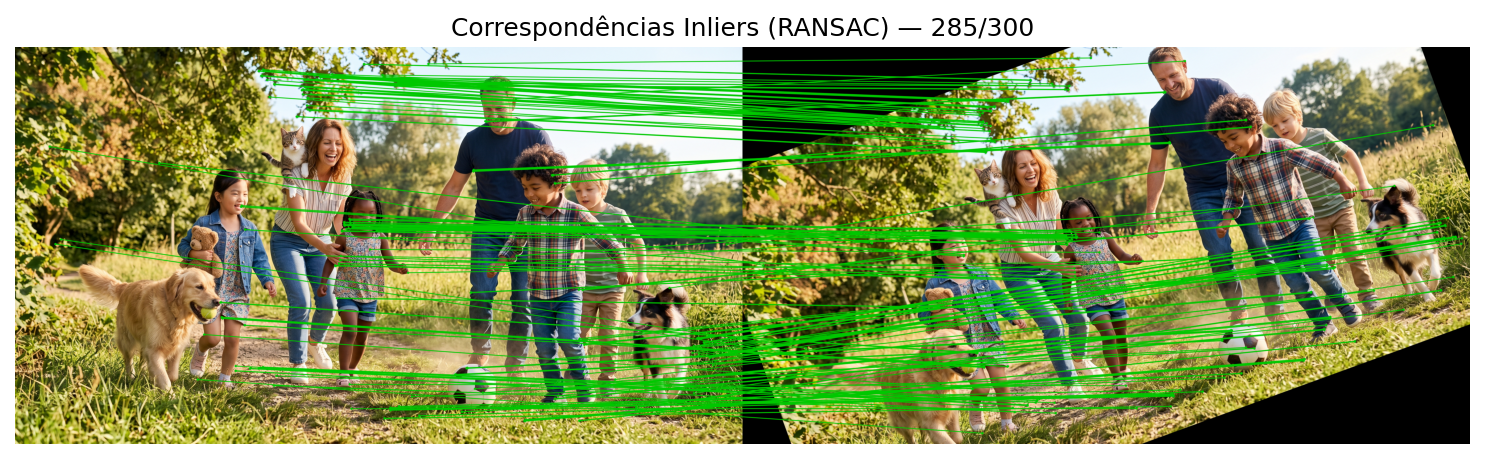

In [40]:
#| label: fig-08-ransac-inliers
#| fig-cap: "Correspondências classificadas como *inliers* (verde) pelo RANSAC ao estimar a homografia entre as duas imagens."
#| echo: true
#| output: true

pts1 = np.float32([kp1[m.queryIdx].pt for m in matches])
pts2 = np.float32([kp2[m.trainIdx].pt for m in matches])

H, mascara_inliers = cv2.findHomography(pts1, pts2, cv2.RANSAC, ransacReprojThreshold=5.0)
n_inliers = int(mascara_inliers.sum())
print(f"Matriz de homografia estimada:\n{H}\n")
print(f"Inliers: {n_inliers} de {len(matches)} correspondências ({100*n_inliers/len(matches):.1f}%)")

matches_inliers = [m for m, ok in zip(matches, mascara_inliers.ravel()) if ok]

img_inliers = draw_matches_destacado(
    img_original, kp1, img_cena, kp2, matches_inliers,
    espessura=2, raio_ponto=4, cor_fixa=(0, 200, 0)  # verde (BGR)
)
mm.show([img_inliers], titles=[f"Correspondências Inliers (RANSAC) — {n_inliers}/{len(matches)}"], cols=1, figsize=(10, 5))

### Registrando a Imagem

Uma vez estimada a homografia, ela pode ser utilizada para registrar a imagem da cena no sistema de coordenadas da imagem original.

O código realiza quatro operações principais:

1. calcula a inversa da homografia;
2. aplica a transformação utilizando `cv2.warpPerspective()`;
3. determina a região válida da imagem registrada;
4. calcula a diferença absoluta entre a imagem registrada e a imagem original.

A @fig-08-image-registration mostra o resultado do registro. Quanto mais precisa for a homografia estimada, menor tende a ser a diferença observada entre as duas imagens, indicando um melhor alinhamento.

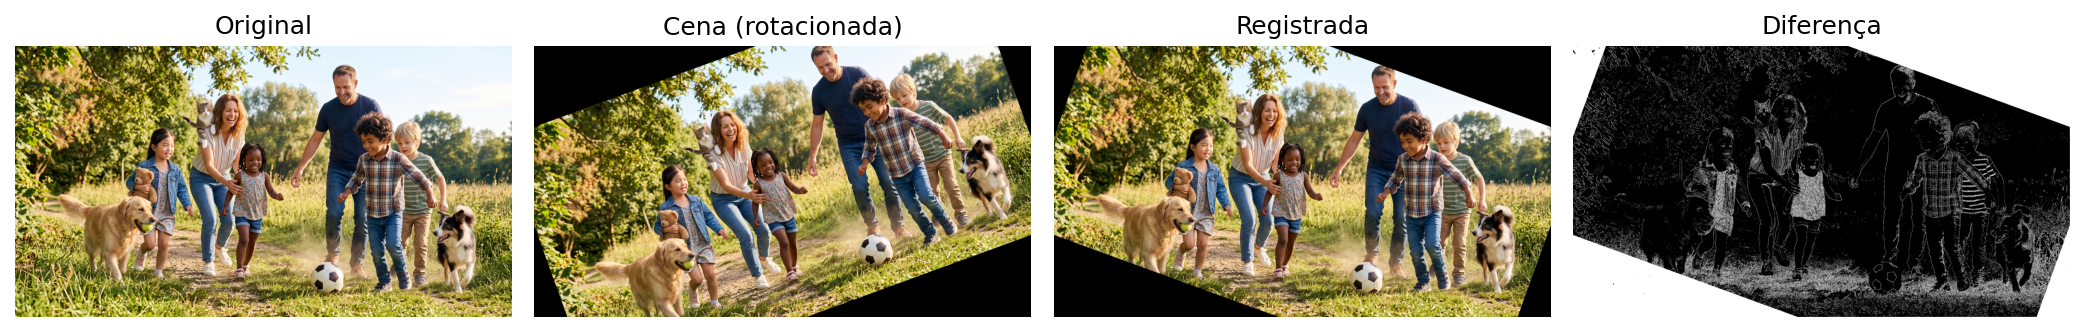

In [48]:
#| label: fig-08-image-registration
#| fig-cap: "Registro da imagem da cena utilizando a homografia inversa estimada pelo RANSAC."
#| echo: true
#| output: true

h, w = img_original.shape[:2]

# WARP_INVERSE_MAP: aplica H "de trás para frente", dispensando o cálculo manual de H^-1
img_registrada = cv2.warpPerspective(img_cena, H, (w, h), flags=cv2.WARP_INVERSE_MAP)

erro = cv2.absdiff(img_original, img_registrada)

mm.show( # mostra mm.gray(erro)>10 em níveis de cinza
    [img_original, img_cena, img_registrada, mm.gray(erro)>10], 
    titles=["Original", "Cena (rotacionada)", "Registrada", "Diferença"],
    cols=4,
    figsize=(14, 4),
)

::: {.callout-note}
## 🧠 Por que funciona? — Robustez por consenso

Ao contrário dos métodos clássicos de mínimos quadrados, que utilizam simultaneamente todos os dados e são fortemente influenciados por *outliers*, o RANSAC ajusta sucessivos modelos a partir de pequenas amostras aleatórias. Cada modelo é então avaliado pelo número de observações compatíveis com ele. Em geral, o modelo correto é aquele que apresenta o maior consenso entre os dados, isto é, o maior número de ***inliers***.

Dois parâmetros exercem papel fundamental no algoritmo:

- o **limiar de reprojeção**, que define a distância máxima para que uma observação seja considerada um ***inlier***;
- o **número de iterações**, que deve ser suficientemente grande para aumentar a probabilidade de selecionar pelo menos uma amostra livre de ***outliers***.

Embora bastante robusto, o RANSAC pressupõe a existência de um único modelo predominante nos dados. Seu desempenho tende a diminuir quando há poucos ***inliers*** ou quando múltiplas estruturas geométricas coexistem na mesma cena.
:::

## Detecção de Objetos: *Haar Cascade* (Viola-Jones)

A correspondência de características responde à pergunta "onde está o mesmo padrão que já conheço?". A **detecção de objetos** resolve um problema mais geral: localizar instâncias de uma **categoria** (por exemplo, faces humanas), mesmo que os objetos específicos nunca tenham sido observados durante o treinamento.

O algoritmo ***Haar Cascade***, proposto por Viola e Jones [@viola2001rapid; @viola2004robust], foi um dos primeiros métodos capazes de detectar faces em tempo real utilizando hardware convencional. Embora atualmente tenha sido amplamente substituído por métodos baseados em redes neurais convolucionais, continua sendo uma excelente ferramenta didática devido à sua simplicidade, eficiência e disponibilidade no OpenCV.

Seu funcionamento baseia-se em três componentes principais:

1. **Características Haar:** filtros retangulares simples que medem diferenças de intensidade entre regiões vizinhas da imagem, explorando padrões típicos de objetos, como a região dos olhos geralmente mais escura que a testa;
2. **Imagem integral:** estrutura de dados que permite calcular rapidamente a soma dos pixels de qualquer região retangular da imagem:
   $$
   I_{\text{integral}}(x,y)=\sum_{x'\le x,\;y'\le y}I(x',y'),
   $$
   reduzindo significativamente o custo computacional da avaliação das características Haar;
3. **Cascata de classificadores:** durante o treinamento, o algoritmo AdaBoost seleciona e combina classificadores simples em uma sequência de estágios. Na detecção, regiões claramente negativas são descartadas logo nos primeiros estágios, enquanto apenas as candidatas mais promissoras passam pelas etapas seguintes, mais precisas e computacionalmente mais caras. Essa estratégia permite realizar uma busca eficiente em diferentes posições e escalas da imagem.

O código a seguir, que gera a @fig-08-haar-deteccao, utiliza classificadores pré-treinados do OpenCV para detectar **faces** e, em seguida, restringe a busca por **olhos** apenas ao interior de cada face detectada. Essa estratégia reduz falsos positivos e diminui o custo computacional, pois evita procurar olhos em toda a imagem.

A função `detectMultiScale()` realiza a busca em múltiplas escalas. O parâmetro `scaleFactor` controla o fator de redução entre escalas consecutivas da janela de busca, enquanto `minNeighbors` define quantas detecções vizinhas são necessárias para confirmar um objeto, reduzindo detecções espúrias. O parâmetro `minSize` estabelece o menor tamanho de objeto que será considerado durante a busca.

Regiões detectadas como face: 5


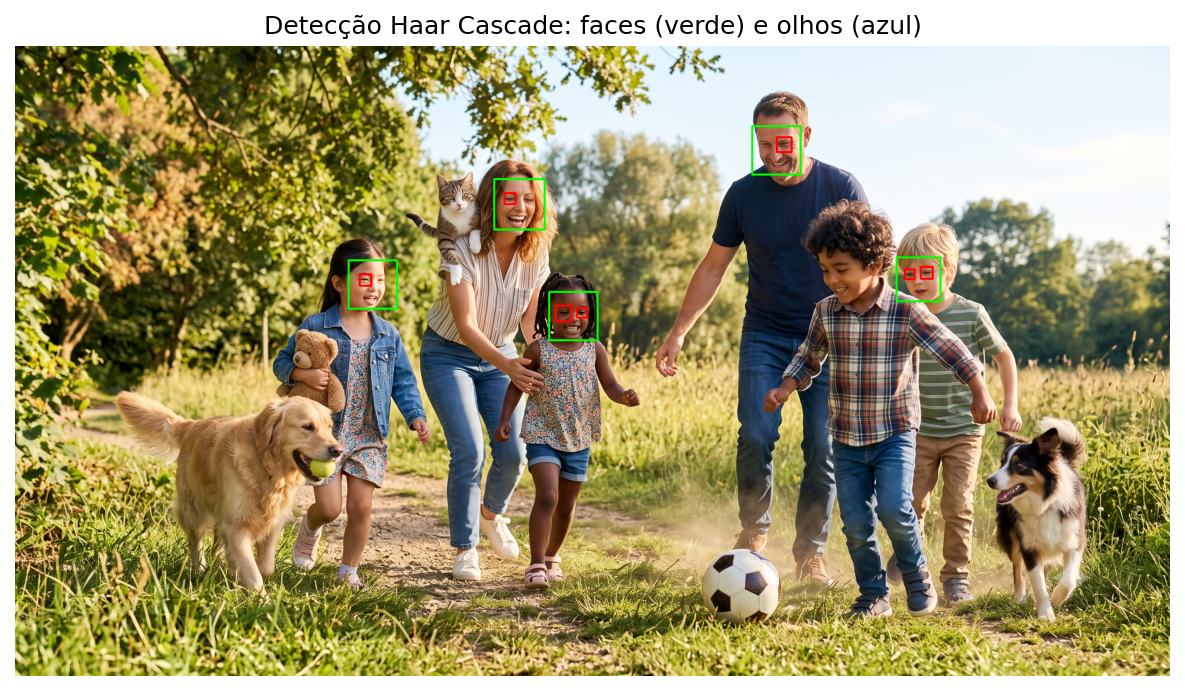

In [75]:
#| label: fig-08-haar-deteccao
#| fig-cap: "Detecção de faces e olhos com *Haar Cascade*."
#| echo: true
#| output: true

def get_cascade(nome):
    """Baixa (se necessário) e carrega um classificador Haar Cascade do OpenCV."""
    caminho = f"haarcascades/{nome}"
    os.makedirs("haarcascades", exist_ok=True)
    if not os.path.exists(caminho):
        url = f"https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/{nome}"
        urllib.request.urlretrieve(url, caminho)
    return cv2.CascadeClassifier(caminho)

# Mais utilizado
#face_cascade = get_cascade("haarcascade_frontalface_default.xml")

# Mais preciso, porém mais lento
face_cascade = get_cascade("haarcascade_frontalface_alt2.xml")

# Compromisso entre velocidade e precisão
#face_cascade = get_cascade("haarcascade_frontalface_alt.xml")

# Muito rápido, porém menos preciso
#face_cascade = get_cascade("haarcascade_frontalface_alt_tree.xml")

# para os olhos, mais utilizado
#eye_cascade = get_cascade("haarcascade_eye.xml")
eye_cascade  = get_cascade("haarcascade_eye_tree_eyeglasses.xml")


img_original = mm.read(caminho_local)

# Escala de cinza + equalização de histograma (Capítulo 3), como o Haar Cascade espera
img_rgb = mm.rotate(img_original, angle=0)
img_gray = cv2.equalizeHist(cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY))

# Detecta faces e, dentro de cada uma, tenta detectar os olhos
faces = face_cascade.detectMultiScale(
    img_gray,
    scaleFactor=1.1,      # Passos maiores entre escalas: mais rápido, porém menos sensível
    minNeighbors=3,       # Nº mínimo de detecções sobrepostas para confirmar uma face
    minSize=(90, 90)      # Ignora regiões candidatas menores que 30×30 px
)

img_anotada = img_rgb.copy()
for (x, y, w, h) in faces:
    cv2.rectangle(img_anotada, (x, y), (x + w, y + h), (0, 255, 0), 3)
    olhos = eye_cascade.detectMultiScale(
        img_gray[y:y+h, x:x+w], 
        scaleFactor=1.02, 
        minNeighbors=4, 
        minSize=(15, 15)
    )
    for (ex, ey, ew, eh) in olhos:
        cv2.rectangle(img_anotada, (x+ex, y+ey), (x+ex+ew, y+ey+eh), (255, 0, 0), 4)

print(f"Regiões detectadas como face: {len(faces)}")
mm.show([img_anotada], titles=["Detecção Haar Cascade: faces (verde) e olhos (azul)"], cols=1, figsize=(8, 8))

::: {.callout-note}
## 🧠 Por que funciona? — E por que também falha

Ao executar a célula anterior, o classificador identifica corretamente o rosto e, dentro dele, os dois olhos. Entretanto, uma segunda região também pode ser marcada como **face**, sobre parte do traje espacial. Esse é um exemplo de **falso positivo**: a distribuição local de intensidades nessa região é suficientemente semelhante aos padrões aprendidos pelos filtros Haar para que a cascata a classifique incorretamente como um rosto.

Esse comportamento evidencia uma das principais limitações do *Haar Cascade*. Como o método utiliza apenas diferenças de intensidade entre regiões retangulares, ele não compreende o significado dos objetos presentes na imagem. Assim, texturas e padrões de contraste semelhantes aos encontrados em faces podem gerar detecções incorretas. Além disso, seu desempenho diminui quando há grandes variações de pose, oclusões, expressões faciais ou condições de iluminação diferentes daquelas presentes durante o treinamento.

Apesar dessas limitações, o *Haar Cascade* continua sendo uma alternativa interessante em aplicações com recursos computacionais limitados, pois apresenta baixo custo de processamento e pode operar em tempo real. Em aplicações que exigem maior robustez e precisão, detectores modernos baseados em redes neurais profundas oferecem desempenho significativamente superior.
:::

## Detecção de Objetos: Caixas Delimitadoras, IoU e NMS

Independentemente da técnica empregada — do *Haar Cascade* aos detectores modernos baseados em redes neurais profundas —, os objetos detectados são normalmente representados por **caixas delimitadoras** (*bounding boxes*), definidas pelas coordenadas $(x_{min}, y_{min}, x_{max}, y_{max})$.

### *Intersection over Union* (IoU)

A métrica **Intersection over Union (IoU)** quantifica a sobreposição entre duas caixas delimitadoras — por exemplo, a detecção produzida pelo algoritmo e a anotação de referência (*ground truth*):

$$
\mathrm{IoU}(A,B)=\frac{\mathrm{área}(A\cap B)}{\mathrm{área}(A\cup B)} \in [0,1].
$$

Quanto mais próximo de 1, maior a concordância entre as caixas; 0 indica ausência de sobreposição. Em muitas aplicações, considera-se uma detecção correta quando $\mathrm{IoU}\ge 0{,}5$.

### Supressão de Não-Máximos (NMS)

Detectores baseados em *sliding window* frequentemente produzem várias caixas sobrepostas para um mesmo objeto. A **Supressão de Não-Máximos** (*Non-Maximum Suppression*, NMS) remove essa redundância em três etapas:

1. ordena as detecções pela confiança, da maior para a menor;
2. mantém a caixa de maior confiança e elimina aquelas cujo IoU com ela excede um limiar;
3. repete o processo com as caixas restantes até que não existam sobreposições relevantes.

O exemplo da @fig-08-iou-nms ilustra esse procedimento com dois objetos, cada um inicialmente representado por várias caixas sobrepostas. Em vez de implementar o algoritmo manualmente, utiliza-se `cv2.dnn.NMSBoxes`, que aplica internamente a mesma lógica de ordenação e supressão por IoU — a abordagem adotada pelos detectores modernos (YOLO, SSD, Faster R-CNN) por sua eficiência. A função `desenhar_caixas` então exibe, lado a lado, as caixas antes e depois do NMS, evidenciando a redução de cinco detecções para apenas duas: uma para cada objeto.

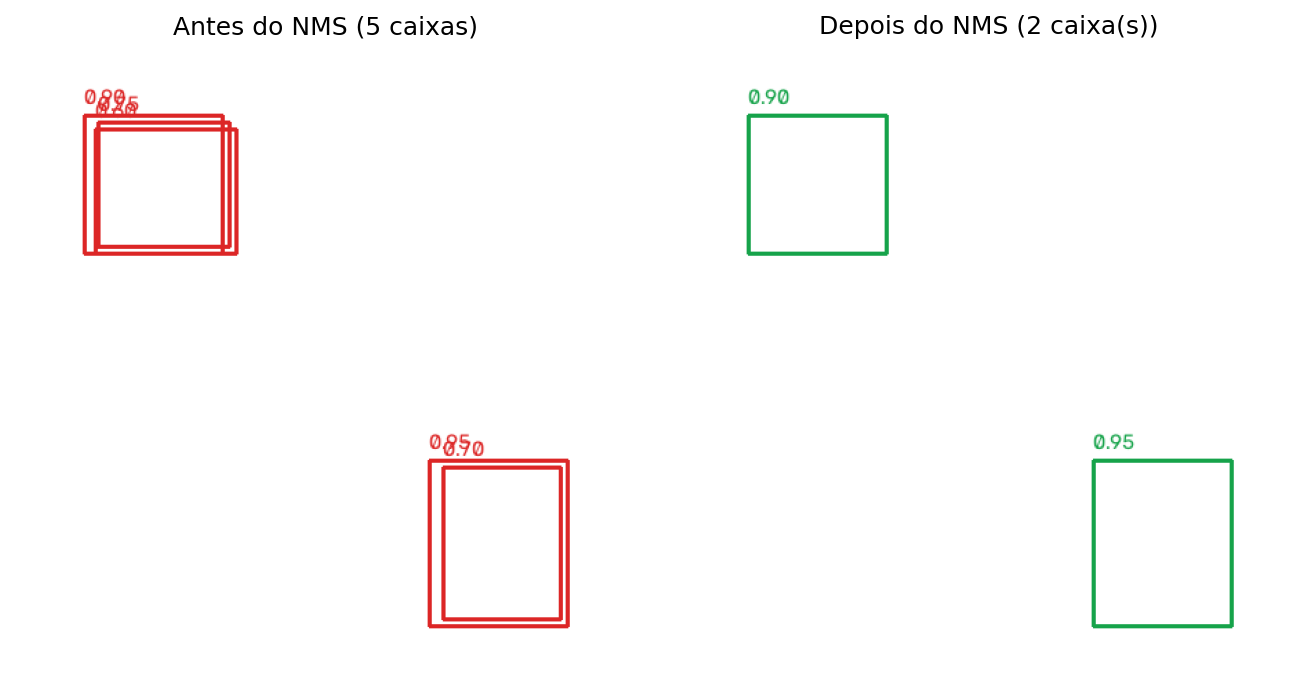

In [83]:
#| label: fig-08-iou-nms
#| fig-cap: "Efeito da Supressão de Não-Máximos (NMS): múltiplas detecções redundantes (esquerda) são reduzidas a uma detecção por objeto (direita)."
#| echo: true
#| output: true

def desenhar_caixas(caixas, pontuacoes, indices, cor, tamanho=(450, 450)):
    """Desenha as caixas (e suas pontuações) indicadas em `indices` sobre um fundo branco."""
    tela = np.full((tamanho[1], tamanho[0], 3), 255, dtype=np.uint8)
    for i in indices:
        x0, y0, x1, y1 = caixas[i]
        cv2.rectangle(tela, (x0, y0), (x1, y1), cor, 2)
        cv2.putText(tela, f"{pontuacoes[i]:.2f}", (x0, y0 - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, cor, 1, cv2.LINE_AA)
    return tela


caixas = np.array([
    [50, 50, 150, 150], [60, 55, 155, 145], [58, 60, 160, 150],
    [300, 300, 400, 420], [310, 305, 395, 415],
])
pontuacoes = np.array([0.90, 0.75, 0.60, 0.95, 0.70])

# cv2.dnn.NMSBoxes espera caixas no formato (x, y, largura, altura)
caixas_xywh = np.column_stack([
    caixas[:, 0], caixas[:, 1],
    caixas[:, 2] - caixas[:, 0], caixas[:, 3] - caixas[:, 1]
])

mantidas = cv2.dnn.NMSBoxes(
    bboxes=caixas_xywh.tolist(),
    scores=pontuacoes.tolist(),
    score_threshold=0.0,   # nenhum corte por confiança mínima aqui
    nms_threshold=0.4      # limiar de IoU para considerar duas caixas redundantes
).flatten()

img_antes = desenhar_caixas(caixas, pontuacoes, range(len(caixas)), cor=(220, 38, 38))
img_depois = desenhar_caixas(caixas, pontuacoes, mantidas, cor=(22, 163, 74))

mm.show(
    [img_antes, img_depois],
    titles=[f"Antes do NMS ({len(caixas)} caixas)", f"Depois do NMS ({len(mantidas)} caixa(s))"],
    cols=2, figsize=(9, 4.5)
)

::: {.callout-note}
## 🧠 Por que funciona? — NMS como "faxina" pós-detecção

O **NMS** não melhora a qualidade das detecções individuais; sua função é eliminar **caixas redundantes** que representam o mesmo objeto, reduzindo-as a uma única caixa delimitadora por objeto.

Sua eficácia depende do limiar de IoU adotado: um valor muito baixo pode descartar detecções de objetos distintos que estejam próximos entre si, enquanto um valor muito alto pode deixar várias caixas sobrepostas para o mesmo objeto.

O NMS **não corrige falsos positivos isolados** — uma região incorretamente detectada apenas uma vez é mantida, pois não há outra caixa redundante para eliminá-la. Por atuar somente sobre a redundância entre detecções sobrepostas, o NMS é aplicado como uma etapa de **pós-processamento**, sempre após a detecção dos objetos.
:::

## Segmentação Visual: Semântica, de Instâncias e Panóptica

Uma caixa delimitadora indica aproximadamente a posição de um objeto, mas não identifica quais pixels lhe pertencem. A **segmentação visual** resolve esse problema atribuindo um rótulo a cada pixel da imagem. Conforme a informação produzida, distinguem-se três paradigmas principais, resumidos na @tbl-08-segmentacao.

| Paradigma | Pergunta que responde | Distingue objetos da mesma classe? |
|---|---|---|
| **Semântica** | "A que classe pertence cada pixel?" | Não. Todos os pixels de uma mesma classe recebem o mesmo rótulo. |
| **De instâncias** | "Quais pixels pertencem a cada objeto individual?" | Sim. Cada objeto recebe um identificador próprio. |
| **Panóptica** | Combina as duas anteriores. | Sim. Cada pixel recebe uma classe e, quando aplicável, um identificador de instância. |

: Comparação entre os principais paradigmas de segmentação visual. {#tbl-08-segmentacao}

Na segmentação **semântica**, todos os pixels são classificados de acordo com sua classe, incluindo regiões de fundo, como céu, vegetação ou estrada. Na segmentação **de instâncias**, objetos pertencentes à mesma classe também são diferenciados entre si. Já a segmentação **panóptica** reúne essas duas informações em uma única representação, atribuindo simultaneamente uma classe e, quando necessário, um identificador de instância a cada pixel.

Antes da popularização das redes neurais profundas — tema do **Capítulo 9** — muitas aplicações eram resolvidas por técnicas clássicas de processamento de imagens. A @fig-08-segmentacao-classica apresenta um exemplo utilizando a imagem de moedas da biblioteca `scikit-image`.

Inicialmente, aplica-se um **fechamento morfológico** para suavizar pequenas imperfeições na superfície das moedas. Em seguida, a **limiarização de Otsu** gera uma máscara binária que separa moedas e fundo, caracterizando uma **segmentação semântica**. Após a remoção de objetos conectados à borda, o preenchimento de pequenas regiões internas e a eliminação de ruídos por operações morfológicas, obtém-se uma máscara binária limpa. Por fim, a **rotulagem de componentes conectados** atribui um identificador diferente a cada moeda, produzindo uma **segmentação de instâncias**.

Instâncias (moedas individuais) identificadas: 24


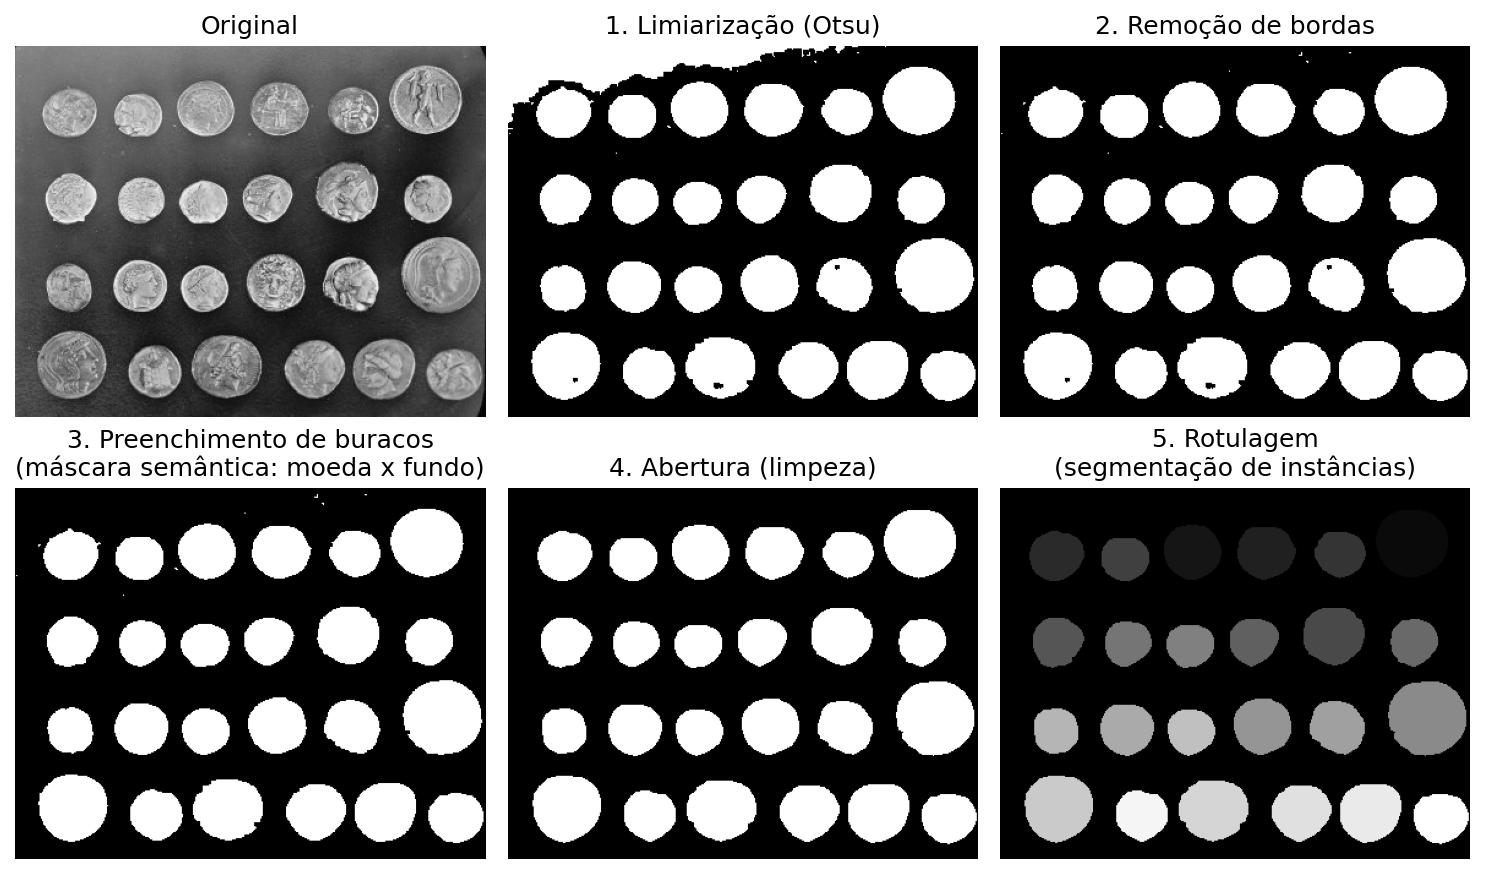

In [142]:
#| label: fig-08-segmentacao-classica
#| fig-cap: "Segmentação clássica (não baseada em aprendizado profundo): máscara semântica (moeda x fundo) via limiarização de Otsu, e segmentação de instâncias via rotulagem de componentes conectados."
#| echo: true
#| output: true

img_moedas = skdata.coins()

# 1. Fechamento morfológico: suaviza bordas e preenche pequenas falhas na
#    superfície das moedas antes da limiarização
fechamento = mm.close(img_moedas, mm.sedisk(4))

# 2. Limiarização de Otsu (Capítulo 4): separa moedas (claras) do fundo (escuro)
mascara_bruta = mm.threshold(fechamento)

# 3. Remove objetos conectados à borda da imagem — moedas cortadas nas
#    extremidades não formam instâncias completas e atrapalhariam a contagem
mascara_sem_borda = mm.edgeoff(mascara_bruta)

# 4. Fechamento de buracos: preenche eventuais regiões internas não detectadas
#    pelo threshold, garantindo que cada moeda seja um disco sólido
mascara_semantica = mm.clohole(mascara_sem_borda)

# 5. Abertura morfológica: remove ruído residual e desconecta moedas que
#    porventura se tocam, preparando a máscara para a rotulagem
mascara_limpa = mm.open(mascara_semantica, mm.sedisk(6))

# 6. Rotulagem de componentes conectados: cada moeda isolada recebe um
#    identificador de instância distinto
rotulos_instancias = mm.label(mascara_limpa)

print(f"Instâncias (moedas individuais) identificadas: {np.max(rotulos_instancias)}")

mm.show(
    [img_moedas, mascara_bruta, mascara_sem_borda, mascara_semantica, mascara_limpa, rotulos_instancias],
    titles=[
        "Original",
        "1. Limiarização (Otsu)",
        "2. Remoção de bordas",
        "3. Preenchimento de buracos\n(máscara semântica: moeda x fundo)",
        "4. Abertura (limpeza)",
        "5. Rotulagem\n(segmentação de instâncias)"
    ],
    cols=3, figsize=(10, 6)
)

::: {.callout-note}
## 🧠 Por que funciona? — E onde a abordagem clássica esbarra

Neste exemplo, a segmentação funciona porque as moedas apresentam intensidade relativamente homogênea e bom contraste em relação ao fundo. A limiarização de Otsu separa eficientemente esses dois grupos, enquanto as operações morfológicas removem pequenos defeitos da máscara binária. Por fim, a rotulagem de componentes conectados identifica cada região conexa como uma instância distinta.

Essa estratégia, entretanto, depende fortemente da qualidade da máscara binária. Se dois objetos estiverem unidos, sobrepostos ou apresentarem contraste insuficiente em relação ao fundo, eles poderão ser fundidos em uma única região ou sequer serem segmentados corretamente. Além disso, métodos baseados apenas em intensidade não conseguem distinguir objetos de classes diferentes que possuam aparência semelhante.

Modelos modernos de segmentação baseados em redes neurais profundas superam essas limitações ao aprender diretamente as características visuais dos objetos, tornando-se muito mais robustos a variações de iluminação, textura, forma e oclusão. A segmentação panóptica amplia essa ideia ao combinar, em uma única representação, a classificação semântica de todos os pixels e a identificação individual dos objetos presentes na cena.
:::

### Alternativa mais robusta: Transformada de Distância + *Watershed*

A abertura morfológica separa moedas que se tocam por meio da erosão da máscara, o que modifica o contorno de todos os objetos, inclusive daqueles que já estavam isolados. Uma alternativa introduzida no Capítulo 4 consiste em combinar a **transformada de distância** com o algoritmo ***watershed***, preservando melhor os contornos originais.

O procedimento é realizado em três etapas:

1. calcula-se a transformada de distância da máscara binária, atribuindo a cada pixel do objeto sua distância até o fundo mais próximo;
2. aplica-se um limiar à transformada de distância para obter marcadores localizados nas regiões centrais das moedas;
3. utiliza-se o algoritmo ***watershed*** para expandir esses marcadores até os limites dos objetos, separando moedas que se encontram em contato.

A @fig-08-watershed apresenta cada uma dessas etapas. Observa-se que os marcadores são gerados apenas nas regiões centrais da transformada de distância e, a partir deles, o *watershed* propaga os rótulos até encontrar as fronteiras entre moedas vizinhas.

Comparando com a abertura morfológica, ambas as abordagens conseguem separar as moedas em contato. Entretanto, como o *watershed* atua sobre a transformada de distância em vez de erodir diretamente a máscara, os contornos dos objetos são preservados com maior fidelidade, produzindo medidas geométricas mais precisas de área, perímetro e circularidade.

Abertura morfológica (mascara_limpa): 24 instâncias
Distância + watershed: 24 instâncias


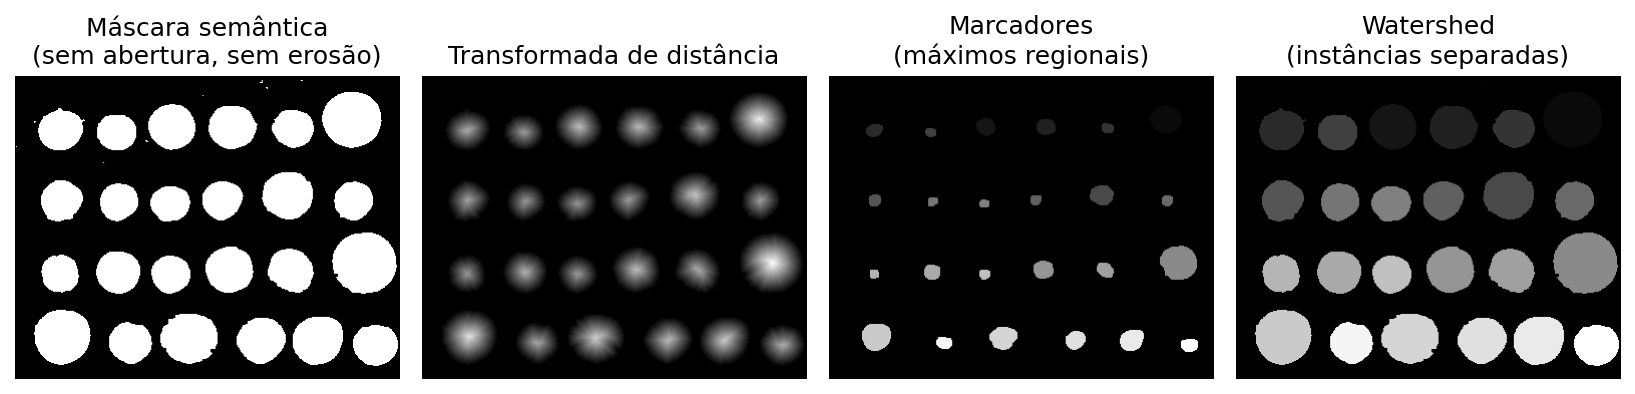

In [ ]:
#| label: fig-08-watershed
#| fig-cap: "Separação de moedas que se tocam via transformada de distância + *watershed*, sem erosão do contorno das moedas."
#| echo: true
#| output: true

# Reaproveita a máscara semântica ANTES da abertura agressiva (sem erosão do contorno)
mascara_base = mascara_semantica

# 1. Transformada de distância: cada pixel da máscara recebe a distância até o fundo mais próximo
distancia = mm.dist(mascara_base)

# Marcadores obtidos por limiarização da transformada de distância.
# As regiões centrais das moedas permanecem conectadas e são utilizadas
# como sementes para o algoritmo watershed.
marcadores = mm.label(
    np.uint8(distancia > 0.5 * distancia.max())
)

# 3. Watershed: propaga cada marcador dentro da máscara até os pontos de contato entre moedas
rotulos_watershed = mm.watershed(marcadores, mascara_base)

print(f"Abertura morfológica (mascara_limpa): {np.max(rotulos_instancias)} instâncias")
print(f"Distância + watershed: {np.max(rotulos_watershed)} instâncias")

mm.show(
    [mascara_base, distancia, mm.dil(marcadores,mm.sedisk(5)), rotulos_watershed],
    titles=[
        "Máscara semântica\n(sem abertura, sem erosão)",
        "Transformada de distância",
        "Marcadores\n(máximos regionais)",
        "Watershed\n(instâncias separadas)"
    ],
    cols=4, figsize=(11, 3.2)
)

::: {.callout-note}
## 🧠 Por que funciona? — Marcadores e *Watershed*

A transformada de distância apresenta valores maiores nas regiões centrais dos objetos e menores próximos às bordas. Ao aplicar um limiar, obtêm-se marcadores localizados no interior de cada moeda, reduzindo a probabilidade de que duas moedas em contato compartilhem o mesmo marcador.

O algoritmo ***watershed*** utiliza esses marcadores como pontos de partida e propaga seus rótulos até que duas regiões em crescimento se encontrem. Essas regiões de encontro definem naturalmente a fronteira entre objetos adjacentes.

O desempenho desse método depende da qualidade dos marcadores. Objetos muito alongados, com formas irregulares ou contendo múltiplas regiões centrais podem originar marcadores extras, resultando em uma segmentação excessiva (*oversegmentation*). Por esse motivo, métodos modernos de segmentação de instâncias utilizam redes neurais profundas para aprender automaticamente a localização e o formato dos objetos, reduzindo a dependência de heurísticas baseadas na geometria da cena.
:::

### Medição e Extração de Atributos com `mm.measure`

Após segmentar as moedas, o próximo passo é medir suas propriedades geométricas. Para isso, a biblioteca `morph` disponibiliza a função `mm.measure`, que recebe uma imagem **binária** e retorna, para cada objeto, um conjunto de descritores geométricos organizados em uma lista de dicionários.

Entre os descritores calculados destacam-se a **área**, o **perímetro**, o **centroide**, a **caixa delimitadora** (*bounding box*), a **circularidade**, a **solidez** e o número de **vértices** do contorno aproximado. Esses vértices são obtidos aproximando o contorno por um polígono simplificado, calculado pela função `approxPolyDP`, que preserva a forma geral do objeto utilizando um número reduzido de segmentos.

A circularidade é definida por

$$
\text{Circularidade}=
\frac{4\pi\cdot\text{Área}}
{\text{Perímetro}^2},
$$

assumindo valor próximo de 1 para objetos aproximadamente circulares.

A solidez é dada por

$$
\text{Solidez}=
\frac{\text{Área}}
{\text{Área do Fecho Convexo}},
$$

indicando o quanto o objeto preenche seu fecho convexo. Valores próximos de 1 caracterizam objetos convexos, enquanto valores menores sugerem a presença de concavidades.

O número de vértices fornece uma indicação da complexidade da forma do objeto. Por exemplo, um triângulo tende a produzir três vértices, um retângulo quatro, enquanto objetos de contorno curvo, como círculos ou moedas, costumam resultar em um polígono com maior número de vértices, dependendo da precisão adotada na aproximação.

Como as moedas apresentam contornos aproximadamente circulares e convexos, espera-se que a circularidade e a solidez permaneçam próximas de 1, enquanto o número de vértices depende do parâmetro de aproximação utilizado. Em conjunto, esses descritores podem ser empregados para identificar automaticamente objetos com formatos distintos ou componentes espúrios remanescentes da segmentação.

In [172]:
#| echo: true
#| output: true

# mm.measure recebe uma imagem binária; cada componente conexo corresponde
# a uma moeda individual.
medidas = mm.measure(mascara_limpa, precision=0.01)

if medidas:
    print(f"Total de objetos catalogados: {len(medidas)}")
    print(f"{'ID':<4}{'Área':<10}{'Perímetro':<12}{'Circularidade':<15}{'Solidez':<10}{'Vértices':<8}")
    for m in medidas:
        print(f"{m['id']:<4}{m['area']:<10.1f}{m['perimeter']:<12.2f}"
              f"{m['circularity']:<15.3f}{m['solidity']:<10.3f}{m['vertices']:<8}")
else:
    print("Nenhuma medida retornada.")

Total de objetos catalogados: 24
ID  Área      Perímetro   Circularidade  Solidez   Vértices
1   1376.5    140.47      0.877          0.979     11      
2   1299.5    136.47      0.877          0.978     10      
3   1628.0    154.37      0.859          0.980     12      
4   1866.0    162.71      0.886          0.985     11      
5   2127.0    178.37      0.840          0.973     12      
6   2328.0    181.68      0.886          0.983     10      
7   1086.5    124.81      0.876          0.979     13      
8   1053.5    121.50      0.897          0.983     9       
9   1399.5    140.47      0.891          0.985     13      
10  1449.0    147.05      0.842          0.972     13      
11  1642.5    153.30      0.878          0.982     13      
12  2987.5    207.58      0.871          0.981     13      
13  1036.5    121.15      0.887          0.981     12      
14  1050.5    123.15      0.870          0.979     11      
15  1110.0    126.23      0.875          0.975     11      
16  113

### Exportação de Anotações: de `mm.measure` ao Formato YOLO

Além dos descritores geométricos, `mm.measure` calcula a caixa delimitadora (*bounding box*) de cada objeto. Essas informações podem ser exportadas automaticamente por `mm.saveMeasures`, permitindo gerar anotações para diferentes aplicações sem necessidade de rotulagem manual.

A função suporta três formatos de saída:

- `fmt="csv"`: exporta todos os descritores geométricos, sendo útil para análise exploratória e classificação baseada em atributos;
- `fmt="txt"`: grava os dados em formato tabular simples;
- `fmt="yolo"`: gera anotações compatíveis com o formato utilizado pelos detectores da família YOLO (*You Only Look Once*).

No formato YOLO, cada objeto é representado por

$$
\text{classe}\;\;x_c\;\;y_c\;\;w\;\;h,
$$

em que as coordenadas do centro e as dimensões da caixa delimitadora são normalizadas pelas dimensões da imagem:

$$
x_c=\frac{x+w/2}{W},
\qquad
y_c=\frac{y+h/2}{H},
\qquad
w_n=\frac{w}{W},
\qquad
h_n=\frac{h}{H}.
$$

Essa representação será utilizada novamente no **Capítulo 9**, dedicado aos detectores baseados em *Deep Learning*.

In [169]:
#| echo: true
#| output: true
 
# Exporta as medidas extraídas das moedas em dois formatos de anotação
altura_img, largura_img = img_moedas.shape[:2]

mm.saveMeasures("moedas.csv", medidas, fmt="csv")
mm.saveMeasures("moedas.txt", medidas, fmt="yolo",
                 img_width=largura_img, img_height=altura_img, class_id=0)

print("--- Trecho de moedas.csv ---")
with open("moedas.csv") as f:
    for linha in f.readlines()[:4]:
        print(linha.rstrip())

print("\n--- Trecho de moedas.txt (formato YOLO) ---")
with open("moedas.txt") as f:
    for linha in f.readlines()[:4]:
        print(linha.rstrip())

--- Trecho de moedas.csv ---
id,area,perimeter,cx,cy,x,y,w,h,circularity,solidity,vertices
1,1376.5,140.47,359.57,268.85,338,250,45,41,0.877,0.979,11
2,1299.5,136.47,115.16,266.56,95,247,42,42,0.877,0.978,10
3,1628.0,154.37,245.55,264.02,222,243,49,46,0.859,0.98,12

--- Trecho de moedas.txt (formato YOLO) ---
0 0.938802 0.892739 0.117188 0.135314
0 0.302083 0.884488 0.109375 0.138614
0 0.641927 0.877888 0.127604 0.151815
0 0.789062 0.877888 0.130208 0.158416


### Validação de Anotações por IoU: `mm.verifyBoundBox`

Anotações geradas automaticamente devem ser comparadas com um conjunto de referência (*ground truth*) antes de serem utilizadas no treinamento de modelos.

A função `mm.verifyBoundBox` realiza essa verificação utilizando a métrica **IoU** (*Intersection over Union*), apresentada anteriormente neste capítulo. Para cada caixa delimitadora candidata, a função calcula sua sobreposição com as caixas do gabarito e contabiliza aquelas cujo IoU supera um limiar predefinido.

No exemplo a seguir, é construído um pequeno conjunto de gabaritos sintéticos para ilustrar o processo de validação.

In [ ]:
#| echo: true
#| output: true

# Matriz de gabaritos sintética no formato (classe, x1, y1, x2, y2), normalizado
gabaritos = np.array([
    [0, *[(m["bbox"][0] + d) / largura_img for d in (0,)],
        (m["bbox"][1]) / altura_img,
        (m["bbox"][0] + m["bbox"][2]) / largura_img,
        (m["bbox"][1] + m["bbox"][3]) / altura_img]
    for m in medidas[:5]
])

acertos = 0
for m in medidas[:5]:
    correspondencias = mm.verifyBoundBox(
        object_id=0, bbox=m["bbox"], matrix=gabaritos,
        width=largura_img, height=altura_img, threshold=0.5
    )
    acertos += int(correspondencias > 0)
    print(f"Objeto {m['id']}: {correspondencias} gabarito(s) casam com IoU >= 0.5")

print(f"\nTotal de objetos validados: {acertos}/{len(medidas[:5])}")

Objeto 1: 1 gabarito(s) casam com IoU >= 0.5
Objeto 2: 1 gabarito(s) casam com IoU >= 0.5
Objeto 3: 1 gabarito(s) casam com IoU >= 0.5
Objeto 4: 1 gabarito(s) casam com IoU >= 0.5
Objeto 5: 1 gabarito(s) casam com IoU >= 0.5

Total de objetos validados: 5/5


::: {.callout-note}
## 🧠 Por que funciona? — Da Segmentação às Anotações

Após segmentar uma imagem, é possível medir automaticamente cada objeto (`mm.measure`) e converter essas medidas em anotações (`mm.saveMeasures`) para diferentes formatos, incluindo o utilizado pelos detectores YOLO. Esse procedimento permite gerar conjuntos iniciais de treinamento em cenários controlados, reduzindo significativamente o trabalho de rotulagem manual.

Antes de utilizar essas anotações no treinamento de modelos, recomenda-se validá-las contra um conjunto de referência. A função `mm.verifyBoundBox` automatiza essa etapa por meio da métrica **IoU**, permitindo identificar anotações incorretas e aumentar a confiabilidade do conjunto de dados.
:::

## Visão Geral dos Modelos Modernos

As técnicas apresentadas neste capítulo — como detectores em cascata, segmentação baseada em limiarização e pós-processamento por IoU e NMS — continuam sendo importantes para compreender os fundamentos da Visão Computacional. Entretanto, muitas aplicações atuais utilizam modelos de **Aprendizado Profundo**, que aprendem diretamente dos dados as características necessárias para detectar e segmentar objetos.

A @tbl-modelos-modernos apresenta algumas das arquiteturas mais utilizadas atualmente. O objetivo é apenas situar essas abordagens e relacioná-las às tarefas estudadas neste capítulo. Os princípios de funcionamento e treinamento desses modelos serão discutidos em detalhes no **Capítulo 9**.

| Modelo | Tarefa | Ideia central |
|---|---|---|
| **YOLO** (*You Only Look Once*) | Detecção de objetos | Detecta objetos em uma única passada pela rede, priorizando velocidade e processamento em tempo real. |
| **Faster R-CNN** | Detecção de objetos | Gera regiões candidatas e as refina antes da classificação, priorizando precisão. |
| **SSD** (*Single Shot Detector*) | Detecção de objetos | Detecta objetos em diferentes escalas em uma única passada, buscando equilíbrio entre velocidade e precisão. |
| **U-Net** | Segmentação semântica | Produz uma máscara que classifica cada pixel da imagem segundo sua classe. |
| **Mask R-CNN** | Segmentação de instâncias | Estende o Faster R-CNN acrescentando a segmentação de cada objeto detectado. |
| **Segment Anything (SAM)** | Segmentação orientada por prompts | Segmenta objetos a partir de indicações como pontos, caixas ou outros prompts, sem treinamento específico para cada nova classe. |

: Principais arquiteturas de Aprendizado Profundo para detecção e segmentação de imagens. {#tbl-modelos-modernos}

Observa-se uma evolução natural entre essas arquiteturas. Modelos como **YOLO**, **Faster R-CNN** e **SSD** produzem caixas delimitadoras para localizar objetos, enquanto **Mask R-CNN** acrescenta a segmentação de cada instância. Já modelos mais recentes, como o **Segment Anything (SAM)**, ampliam esse conceito ao permitir segmentar objetos a partir de diferentes tipos de interação do usuário. Essa evolução acompanha a transição apresentada neste capítulo: da localização aproximada por caixas delimitadoras para a identificação precisa dos pixels pertencentes a cada objeto.

## Limitações das Abordagens Clássicas e Motivação para o Deep Learning

Os exemplos desenvolvidos neste capítulo ilustram três problemas fundamentais da Visão Computacional: **correspondência de características**, **detecção de objetos** e **segmentação de imagens**. Embora as técnicas clássicas apresentadas sejam eficientes em diversos cenários, todas compartilham uma limitação importante: dependem de características projetadas manualmente.

- O **ORB** utiliza descritores binários capazes de reconhecer pontos correspondentes sob rotações e mudanças moderadas de escala, mas não foi concebido para identificar categorias de objetos.
- O **Haar Cascade** emprega um conjunto fixo de filtros retangulares, funcionando bem para objetos com aparência relativamente padronizada, como faces frontais, mas tornando-se mais suscetível a falsos positivos em cenas complexas.
- A **segmentação por limiarização** explora diferenças de intensidade entre objeto e fundo, sendo adequada para imagens com bom contraste, porém limitada quando há variações de iluminação, texturas ou múltiplas classes de objetos.

Essas limitações decorrem de um mesmo princípio: as características utilizadas pelos algoritmos são definidas previamente pelo projetista. Como discutido ao final do **Capítulo 7**, essa abordagem torna-se insuficiente diante da grande variabilidade encontrada em imagens reais, envolvendo mudanças de pose, iluminação, escala, oclusões e diversidade de categorias.

O **Capítulo 9** apresenta uma abordagem diferente para esse problema por meio das **Redes Neurais Convolucionais (CNNs)**. Em vez de utilizar descritores projetados manualmente, esses modelos aprendem automaticamente, a partir de grandes conjuntos de dados, quais características são mais adequadas para cada tarefa. As arquiteturas modernas apresentadas na seção anterior — como **YOLO**, **Faster R-CNN**, **U-Net**, **Mask R-CNN** e **Segment Anything (SAM)** — baseiam-se nesse mesmo princípio e representam a evolução natural das técnicas clássicas estudadas neste capítulo.

## Resumo

Neste capítulo foram estudados métodos clássicos de Visão Computacional para **correspondência de características**, **detecção de objetos** e **segmentação de imagens**, além de uma breve introdução aos modelos modernos de Aprendizado Profundo. Os principais conceitos apresentados foram:

- **ORB:** detecção de pontos de interesse, descrição por vetores binários e correspondência de características utilizando a distância de Hamming.
- **Homografia e RANSAC:** estimação robusta de transformações projetivas para registro de imagens e eliminação de correspondências inconsistentes.
- **Haar Cascade:** detecção de objetos baseada em filtros de Haar, imagem integral e classificadores em cascata.
- **Segmentação clássica:** limiarização, operações morfológicas, rotulagem de componentes conexos e separação de objetos por transformada de distância e watershed.
- **Extração de atributos:** medição de propriedades geométricas dos objetos com `mm.measure` e geração automática de anotações em formato YOLO.
- **Avaliação de detecções:** utilização da métrica IoU e do algoritmo de Supressão de Não-Máximos (NMS).
- **Modelos modernos:** visão geral das arquiteturas YOLO, Faster R-CNN, SSD, U-Net, Mask R-CNN e Segment Anything (SAM), que serão estudadas em maior profundidade no próximo capítulo.

### Próximos Passos {.unnumbered}

Os métodos clássicos apresentados neste capítulo mostram como problemas de correspondência, detecção e segmentação podem ser resolvidos por meio de descritores, filtros e modelos geométricos projetados manualmente.

No próximo capítulo será apresentado um novo paradigma baseado em **Redes Neurais Convolucionais (CNNs)**. Em vez de definir previamente quais características devem ser utilizadas, esses modelos aprendem automaticamente representações diretamente dos dados de treinamento, constituindo a base dos principais sistemas modernos de Visão Computacional.

## 🤖 Uso do NotebookLM como Tutor Complementar

O **NotebookLM** pode ser utilizado como ferramenta de apoio para revisar os conceitos apresentados neste capítulo. A partir do material fornecido como referência, ele é capaz de responder perguntas, elaborar resumos e explicar conceitos de forma interativa.

::: {.callout-important appearance="default" icon=false}

### 🎓 Estude com o Tutor Inteligente {.unnumbered}

[🚀 ACESSAR NOTEBOOKLM: CAPÍTULO 08](https://notebooklm.google.com/)

As respostas do NotebookLM são geradas automaticamente e podem conter imprecisões. Utilize-as como complemento ao estudo, sempre confrontando as informações com o conteúdo deste livro e com outras fontes acadêmicas quando necessário.

:::

## Lista de Exercícios

Os exercícios a seguir consolidam os conceitos apresentados neste capítulo por meio de adaptações, experimentos e extensões dos algoritmos desenvolvidos ao longo do texto, explorando o uso da biblioteca didática `morph`.

1. **(10%)** Investigue a influência de transformações geométricas severas na estabilidade do detector e descritor ORB. Utilizando a imagem `skimage.data.astronaut()`, gere versões rotacionadas em ângulos de $\{0^\circ, 45^\circ, 90^\circ, 135^\circ, 180^\circ\}$ e, para cada caso, calcule o número total de correspondências iniciais obtidas pelo `BFMatcher` e a fração final de *inliers* validados pelo algoritmo RANSAC. Apresente os resultados em uma tabela e discuta a robustez do método às rotações testadas.
2. **(15%)** Desenvolva uma análise comparativa de desempenho entre o detector de cantos FAST e o detector clássico de Harris (estudado no Capítulo 6) sob o aspecto de custo computacional e repetibilidade. Meça o tempo de execução médio para a extração de pontos de interesse em três imagens com diferentes densidades de textura (`skimage.data.camera()`, `skimage.data.gravel()` e `skimage.data.brick()`) e elabore um relatório técnico detalhando as vantagens pragmáticas de cada abordagem.
3. **(15%)** Investigue a sensibilidade do algoritmo Haar Cascade à presença de ruído e desfoque na imagem de entrada. Adicione ruído gaussiano ($\sigma \in \{5, 10, 20\}$) e desfoque de movimento à imagem `skimage.data.astronaut()`, execute a detecção de faces com diferentes parametrizações do método `detectMultiScale` (variando os parâmetros `scaleFactor` e `minNeighbors`) e descreva os impactos destas perturbações nas taxas de falsos positivos e falsos negativos.
4. **(15%)** Implemente manualmente a métrica *Intersection over Union* (IoU) para caixas delimitadoras e compare a sua lógica com a implementação do método nativo `mm.IoU`. Em seguida, construa um conjunto contendo uma caixa padrão de gabarito e dez caixas propostas (geradas por perturbações de escala e deslocamento espacial da caixa original) e plote um gráfico de linha relacionando o erro médio de translação à queda percentual do índice IoU obtido.
5. **(15%)** Desenvolva um script para avaliar a eficiência do algoritmo de Supressão de Não-Máximos (NMS) apresentado no capítulo. Crie um cenário sintético contendo três objetos hipotéticos espalhados pela cena, onde cada objeto possui um agrupamento de pelo menos cinco caixas delimitadoras sobrepostas com diferentes pontuações de confiança. Execute o algoritmo com limiares de IoU de $\{0{,}2, 0{,}4, 0{,}6, 0{,}8\}$, visualize o efeito em cada limiar utilizando `matplotlib` e discuta o compromisso envolvido na seleção do limiar de NMS ideal.
6. **(15%)** Estenda o pipeline de extração morfológica demonstrado neste capítulo (Otsu, limpeza morfológica e `mm.measure`) para o conjunto completo de moedas de `skimage.data.coins()`, sem se limitar aos cinco primeiros objetos exibidos no texto. Exporte as medidas completas com `mm.saveMeasures` em formato CSV e produza, com `pandas` ou `matplotlib`, histogramas das distribuições de circularidade e solidez, discutindo se essas duas grandezas seriam suficientes para separar moedas de diferentes denominações apenas pela forma.
7. **(15%)** Construa uma cena sintética com pelo menos três classes de formas geométricas (círculos, retângulos e triângulos), algumas delas parcialmente sobrepostas, e aplique o pipeline de segmentação, `mm.measure` e `mm.saveMeasures(fmt="yolo")` demonstrado neste capítulo para gerar as anotações automaticamente. Em seguida, perturbe deliberadamente cada `bbox` obtida (pequenos deslocamentos e variações de escala, simulando um detector imperfeito) e utilize `mm.verifyBoundBox` para quantificar, em diferentes limiares de IoU, quantas anotações permaneceriam válidas. Discuta como a sobreposição entre objetos afeta a qualidade das anotações extraídas por rotulagem de componentes conexos.
8. **(Bônus – 10%)** Construa um classificador estatístico simples (como o classificador k-NN estudado no Capítulo 7 ou uma árvore de decisão simples) utilizando exclusivamente os atributos geométricos extraídos pela função `mm.measure` (como área, circularidade, solidez e contagem de vértices obtida por `approxPolyDP`). Treine e avalie o modelo utilizando um pequeno conjunto de componentes sintéticos (como círculos, retângulos e triângulos contendo variações de escala e rotação) e reporte a acurácia obtida, demonstrando a utilidade pragmática dos descritores clássicos na análise de formas.

## Referências do Capítulo {.unnumbered}

Os conceitos e algoritmos apresentados neste capítulo foram fundamentados nas seguintes referências clássicas e atuais da literatura:

- @gonzalez2018digital, para os fundamentos de segmentação, operações morfológicas, rotulagem de componentes conexos e extração de atributos geométricos.
- @szeliski2022, para os conceitos de correspondência de características, homografias, RANSAC, detecção de objetos e segmentação em Visão Computacional.
- @rublee2011orb, para a descrição do algoritmo **ORB** (*Oriented FAST and Rotated BRIEF*), utilizado na detecção, descrição e correspondência de características locais.
- @fischler1981random, para a formulação original do algoritmo **RANSAC**, amplamente empregado na estimação robusta de modelos geométricos.
- @viola2001rapid, @viola2004robust e @lienhart2002extended, para os fundamentos e a evolução do detector **Haar Cascade**, incluindo a imagem integral, os classificadores em cascata e a extensão das características de Haar implementadas no OpenCV.
- @kirillov2019panoptic, para a definição da **segmentação panóptica**, que integra segmentação semântica e segmentação de instâncias em uma única representação.
- @redmon2016you, @ren2015faster, @ronneberger2015u, @he2017mask e @kirillov2023segment, para as arquiteturas modernas de Aprendizado Profundo aplicadas à detecção e segmentação de imagens, incluindo **YOLO**, **Faster R-CNN**, **U-Net**, **Mask R-CNN** e **Segment Anything (SAM)**.